In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading.epidataloader import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from src.utils.constants import *

epidata_nuts2 = GNNDataLoader('influenza', data_env, nuts_level='nuts2', min_date='2006-05-15',max_date='2020-06-01', include_population=True, periods = 12, prediction_horizon=4)
epidata_nuts2.add_time_features()
epidata_nuts2.log_transform_target()
epidata_nuts2.set_splits()
epidata_nuts2.normalize()
epidata_nuts2.add_lagged_features(lags = range(2,3))
epidata_nuts2.finalize()

epidata_nuts2_id  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'identity_graph').construct_dataloaders()
epidata_nuts2_bn  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'boolean_neighbors_self0').construct_dataloaders()
epidata_nuts2_gm1 = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'gravity_model_dense').construct_dataloaders()
epidata_nuts2_gm2 = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'gravity_model_sparse').construct_dataloaders()


# epidata_nuts3 = GNNDataLoader('influenza', data_env, nuts_level='nuts3', min_date='2006-05-15',max_date='2020-06-01', include_population=True, periods = 12, prediction_horizon=4)
# epidata_nuts3.add_time_features()
# epidata_nuts3.log_transform_target()
# epidata_nuts3.set_splits()
# epidata_nuts3.normalize()
# epidata_nuts3.add_lagged_features(lags = range(2,3))
# epidata_nuts3.finalize()

# epidata_nuts3_id  = epidata_nuts3.copy(deep=True).retrieve_graph(graphname = 'identity_graph').construct_dataloaders()
# epidata_nuts3_bn  = epidata_nuts3.copy(deep=True).retrieve_graph(graphname = 'boolean_neighbors_self0').construct_dataloaders()
# epidata_nuts3_gm1 = epidata_nuts3.copy(deep=True).retrieve_graph(graphname = 'gravity_model_dense').construct_dataloaders()
# epidata_nuts3_gm2 = epidata_nuts3.copy(deep=True).retrieve_graph(graphname = 'gravity_model_sparse').construct_dataloaders()

GNN temporal windowing: extending data collection from 2020-06-01 to 2020-09-14 (+15 weeks)
GNN temporal windowing: extending data collection from 2020-06-01 to 2020-09-14 (+15 weeks)
GNN temporal windowing: extending data collection from 2020-06-01 to 2020-09-14 (+15 weeks)
GNN temporal windowing: extending data collection from 2020-06-01 to 2020-09-14 (+15 weeks)
GNN temporal windowing: extending data collection from 2020-06-01 to 2020-09-14 (+15 weeks)


TODO : Make experiment setup, run and compare the output of a single experiment

In [3]:
from src.models.spatialgcn_baseline import SpatialGCNModel
from src.models.a3tgcn import A3TGCNModel

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⚠️  Input features are 3D (e.g., sequences). Only the last dimension will be used (flattened).

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: <src.dataloading.graphdataloader.GraphDataLoaderEntry object at 0x7f2d88981310>
Epoch 1 train loss: 0.5105, val loss: 0.9343 ✓ (new best)
Epoch 2 train loss: 0.4881, val loss: 0.8549 ✓ (new best)
Epoch 3 train loss: 0.4722, val loss: 0.7908 ✓ (new best)
Epoch 4 train loss: 0.4599, val loss: 0.7349 ✓ (new best)
Epoch 5 train loss: 0.4504, val loss: 0.6863 ✓ (new best)
Epoch 6 train loss: 0.4429, val loss: 0.6450 ✓ (new best)
Epoch 7 train loss: 0.4368, val loss: 0.6105 ✓ (new best)
Epoch 8 train loss: 0.4318, val loss: 0.5812 ✓ (new best)
Epoch 9 train loss: 0.4276, val loss: 0.5568 ✓ (new best)
Epoch 10 train loss: 0.4240, val loss: 0.5372 ✓ (new best)
Epoch 11 train loss: 0.4206, val loss: 0.5203 ✓ (new best)
Epoch 12 train lo

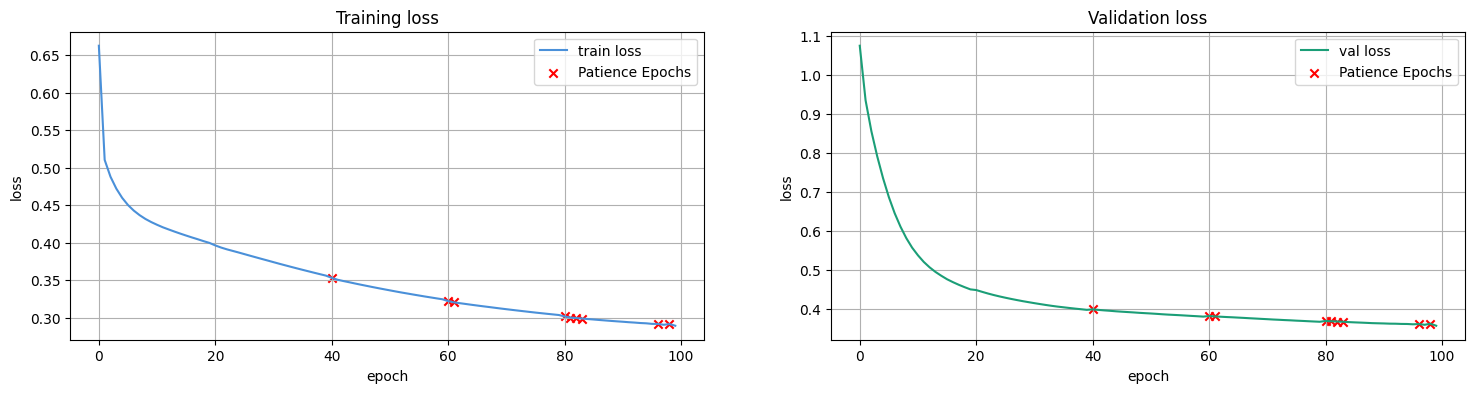

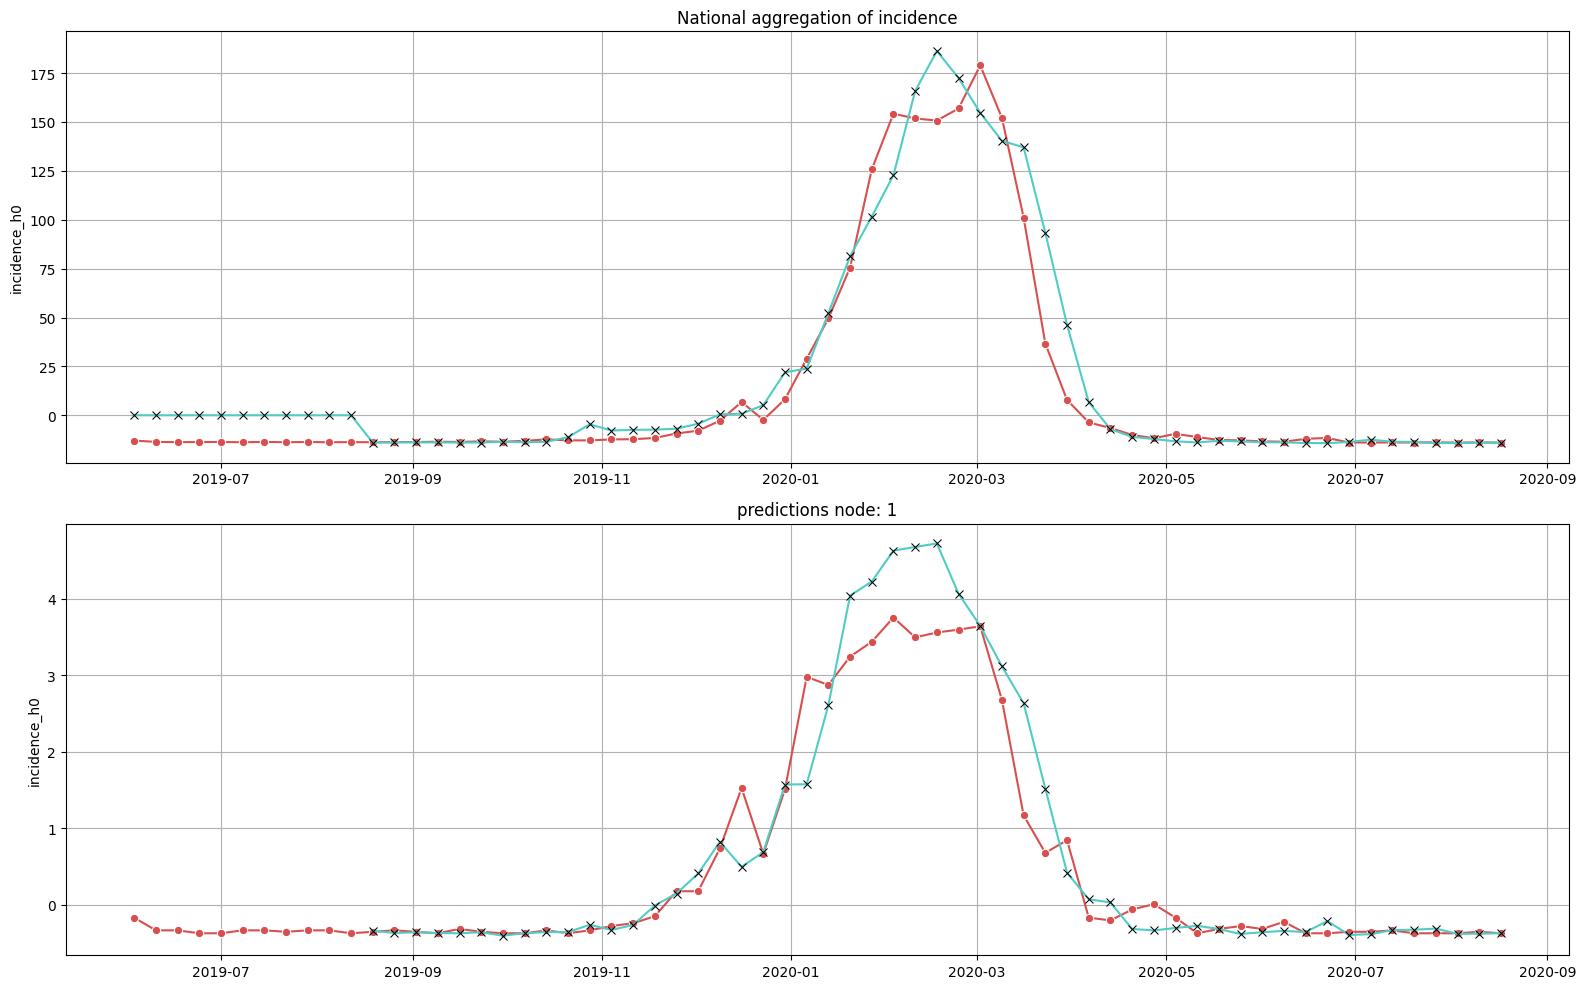

⚠️  Input features are 3D (e.g., sequences). Only the last dimension will be used (flattened).

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: <src.dataloading.graphdataloader.GraphDataLoaderEntry object at 0x7f2d88dee890>
Epoch 1 train loss: 0.5541, val loss: 0.9959 ✓ (new best)
Epoch 2 train loss: 0.5253, val loss: 0.9195 ✓ (new best)
Epoch 3 train loss: 0.5069, val loss: 0.8509 ✓ (new best)
Epoch 4 train loss: 0.4936, val loss: 0.7984 ✓ (new best)
Epoch 5 train loss: 0.4832, val loss: 0.7538 ✓ (new best)
Epoch 6 train loss: 0.4752, val loss: 0.7178 ✓ (new best)
Epoch 7 train loss: 0.4682, val loss: 0.6891 ✓ (new best)
Epoch 8 train loss: 0.4625, val loss: 0.6630 ✓ (new best)
Epoch 9 train loss: 0.4581, val loss: 0.6427 ✓ (new best)
Epoch 10 train loss: 0.4539, val loss: 0.6251 ✓ (new best)
Epoch 11 train loss: 0.4503, val loss: 0.6089 ✓ (new best)
Epoch 12 train lo

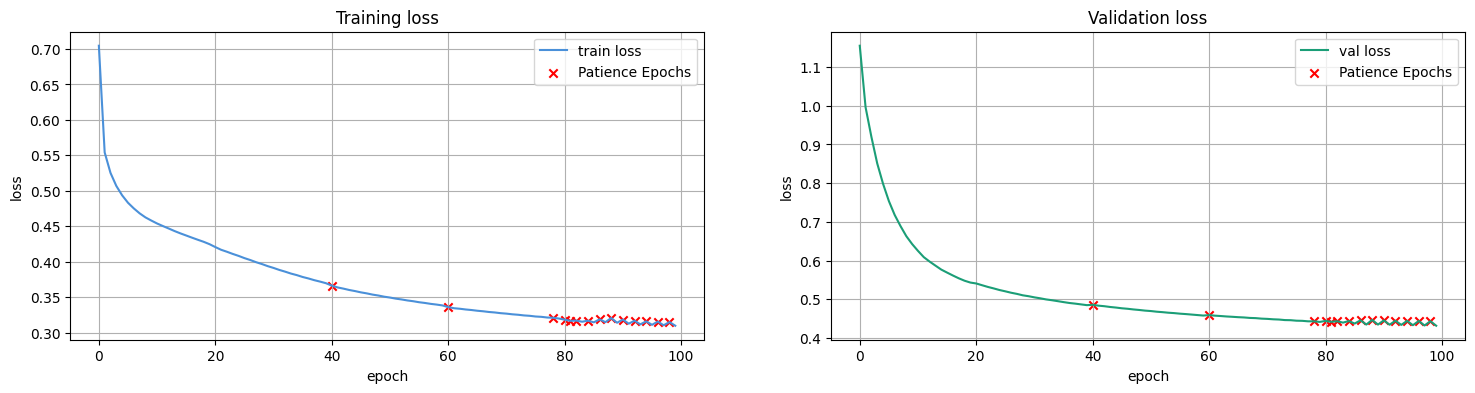

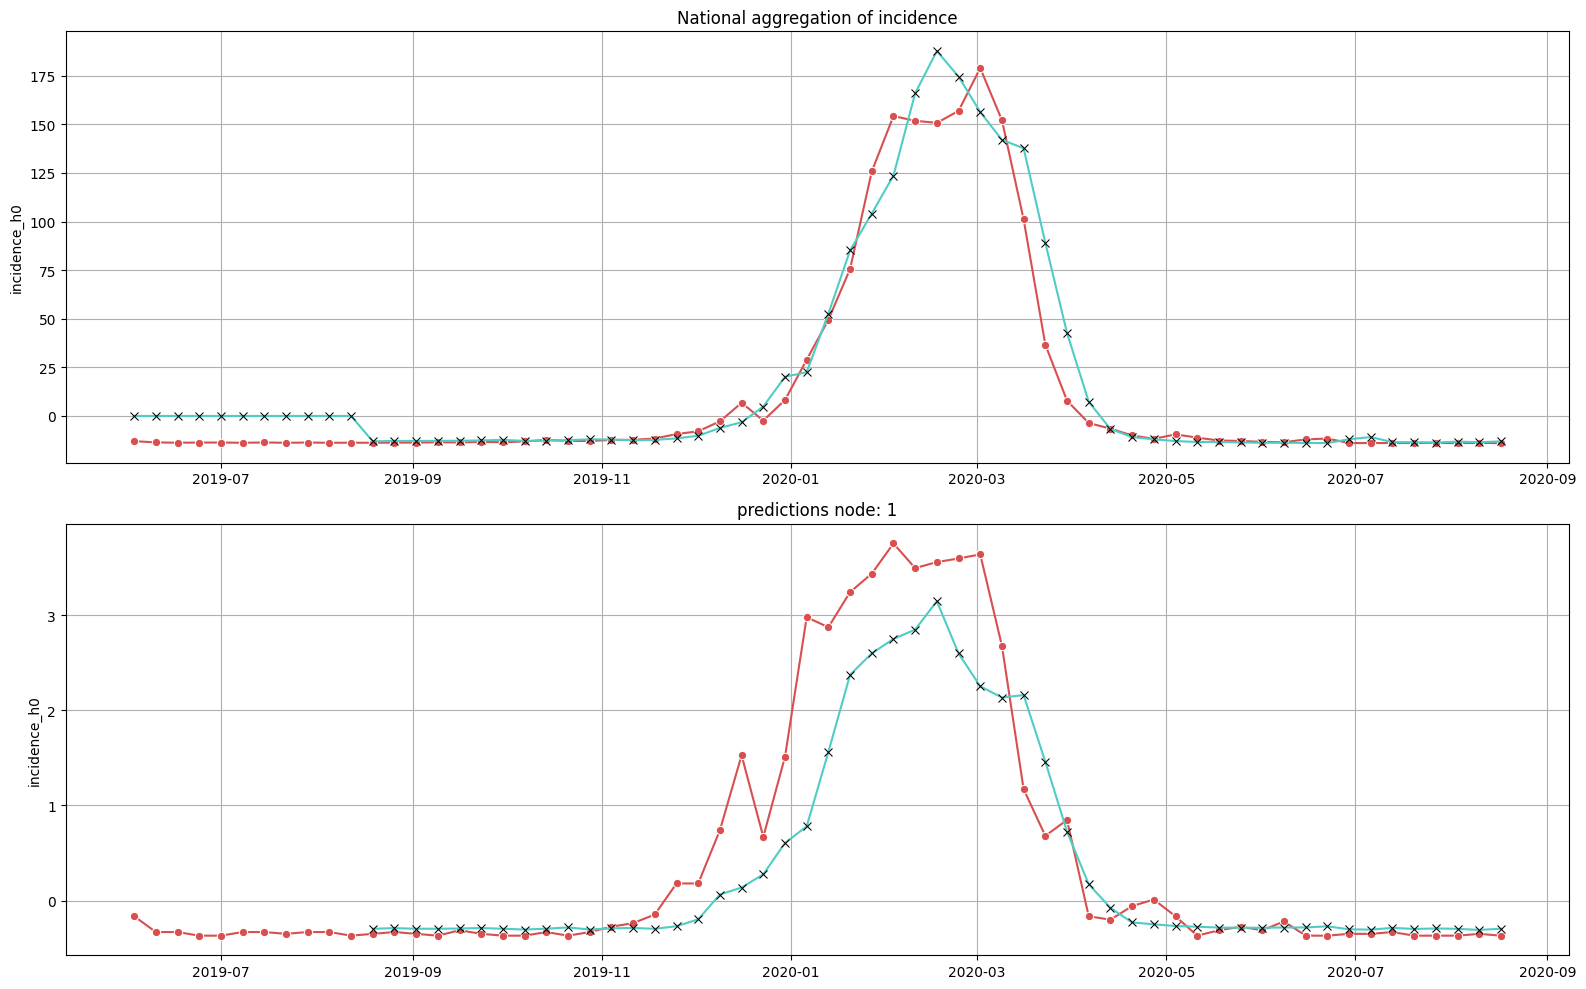

⚠️  Input features are 3D (e.g., sequences). Only the last dimension will be used (flattened).

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: <src.dataloading.graphdataloader.GraphDataLoaderEntry object at 0x7f2d886de250>
Epoch 1 train loss: 0.5900, val loss: 1.1217 ✓ (new best)
Epoch 2 train loss: 0.5608, val loss: 1.0334 ✓ (new best)
Epoch 3 train loss: 0.5442, val loss: 0.9632 ✓ (new best)
Epoch 4 train loss: 0.5324, val loss: 0.9133 ✓ (new best)
Epoch 5 train loss: 0.5230, val loss: 0.8712 ✓ (new best)
Epoch 6 train loss: 0.5163, val loss: 0.8362 ✓ (new best)
Epoch 7 train loss: 0.5110, val loss: 0.8081 ✓ (new best)
Epoch 8 train loss: 0.5070, val loss: 0.7859 ✓ (new best)
Epoch 9 train loss: 0.5034, val loss: 0.7678 ✓ (new best)
Epoch 10 train loss: 0.5004, val loss: 0.7529 ✓ (new best)
Epoch 11 train loss: 0.4971, val loss: 0.7387 ✓ (new best)
Epoch 12 train lo

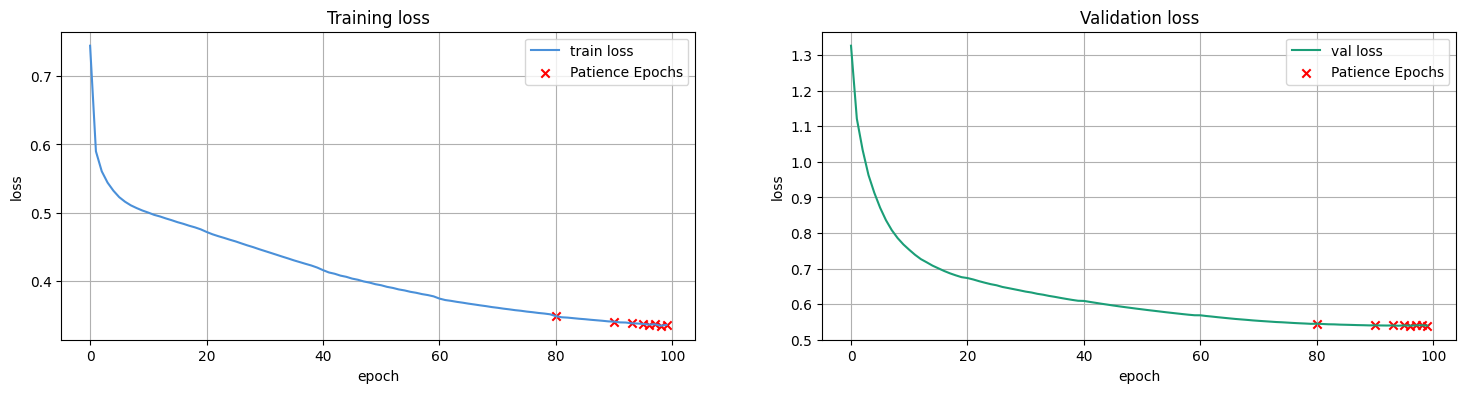

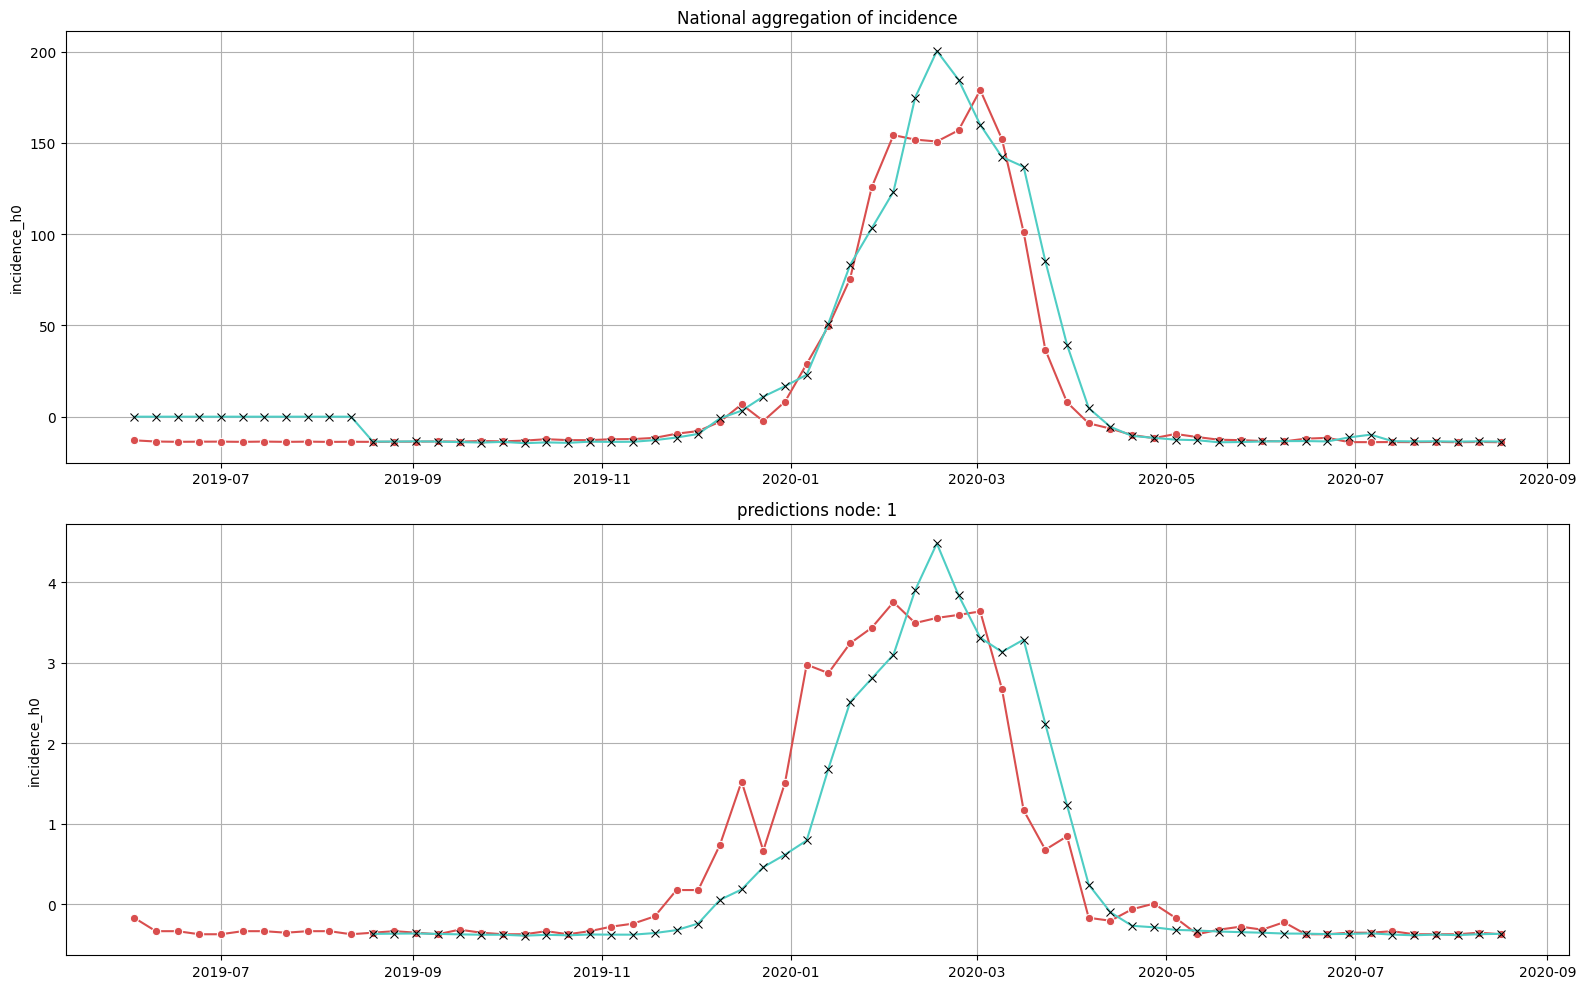

⚠️  Input features are 3D (e.g., sequences). Only the last dimension will be used (flattened).

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: <src.dataloading.graphdataloader.GraphDataLoaderEntry object at 0x7f2d88c49d10>
Epoch 1 train loss: 0.5471, val loss: 0.9797 ✓ (new best)
Epoch 2 train loss: 0.5225, val loss: 0.8971 ✓ (new best)
Epoch 3 train loss: 0.5077, val loss: 0.8373 ✓ (new best)
Epoch 4 train loss: 0.4963, val loss: 0.7879 ✓ (new best)
Epoch 5 train loss: 0.4875, val loss: 0.7483 ✓ (new best)
Epoch 6 train loss: 0.4804, val loss: 0.7151 ✓ (new best)
Epoch 7 train loss: 0.4748, val loss: 0.6870 ✓ (new best)
Epoch 8 train loss: 0.4697, val loss: 0.6647 ✓ (new best)
Epoch 9 train loss: 0.4657, val loss: 0.6453 ✓ (new best)
Epoch 10 train loss: 0.4618, val loss: 0.6296 ✓ (new best)
Epoch 11 train loss: 0.4585, val loss: 0.6165 ✓ (new best)
Epoch 12 train lo

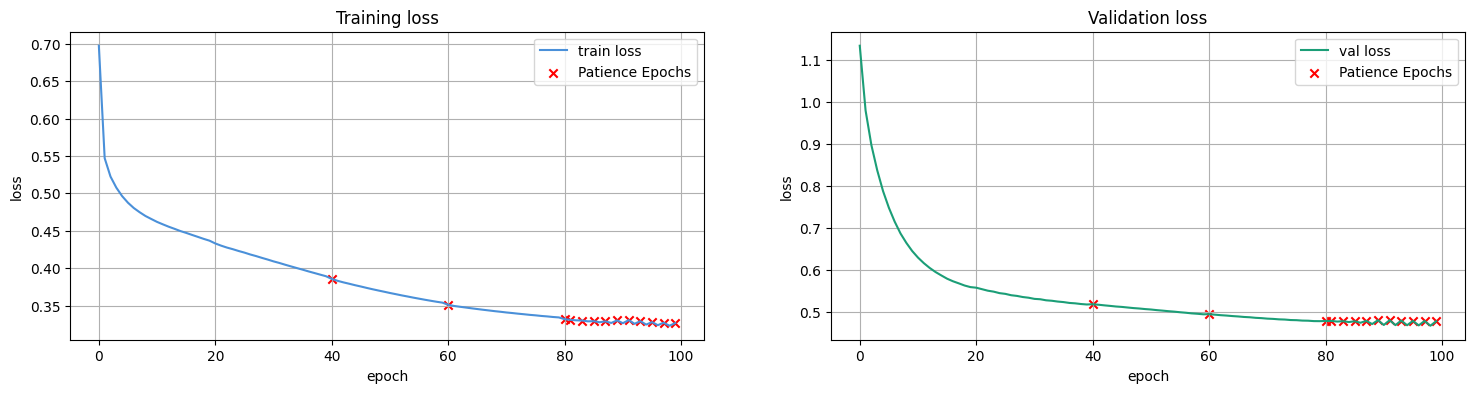

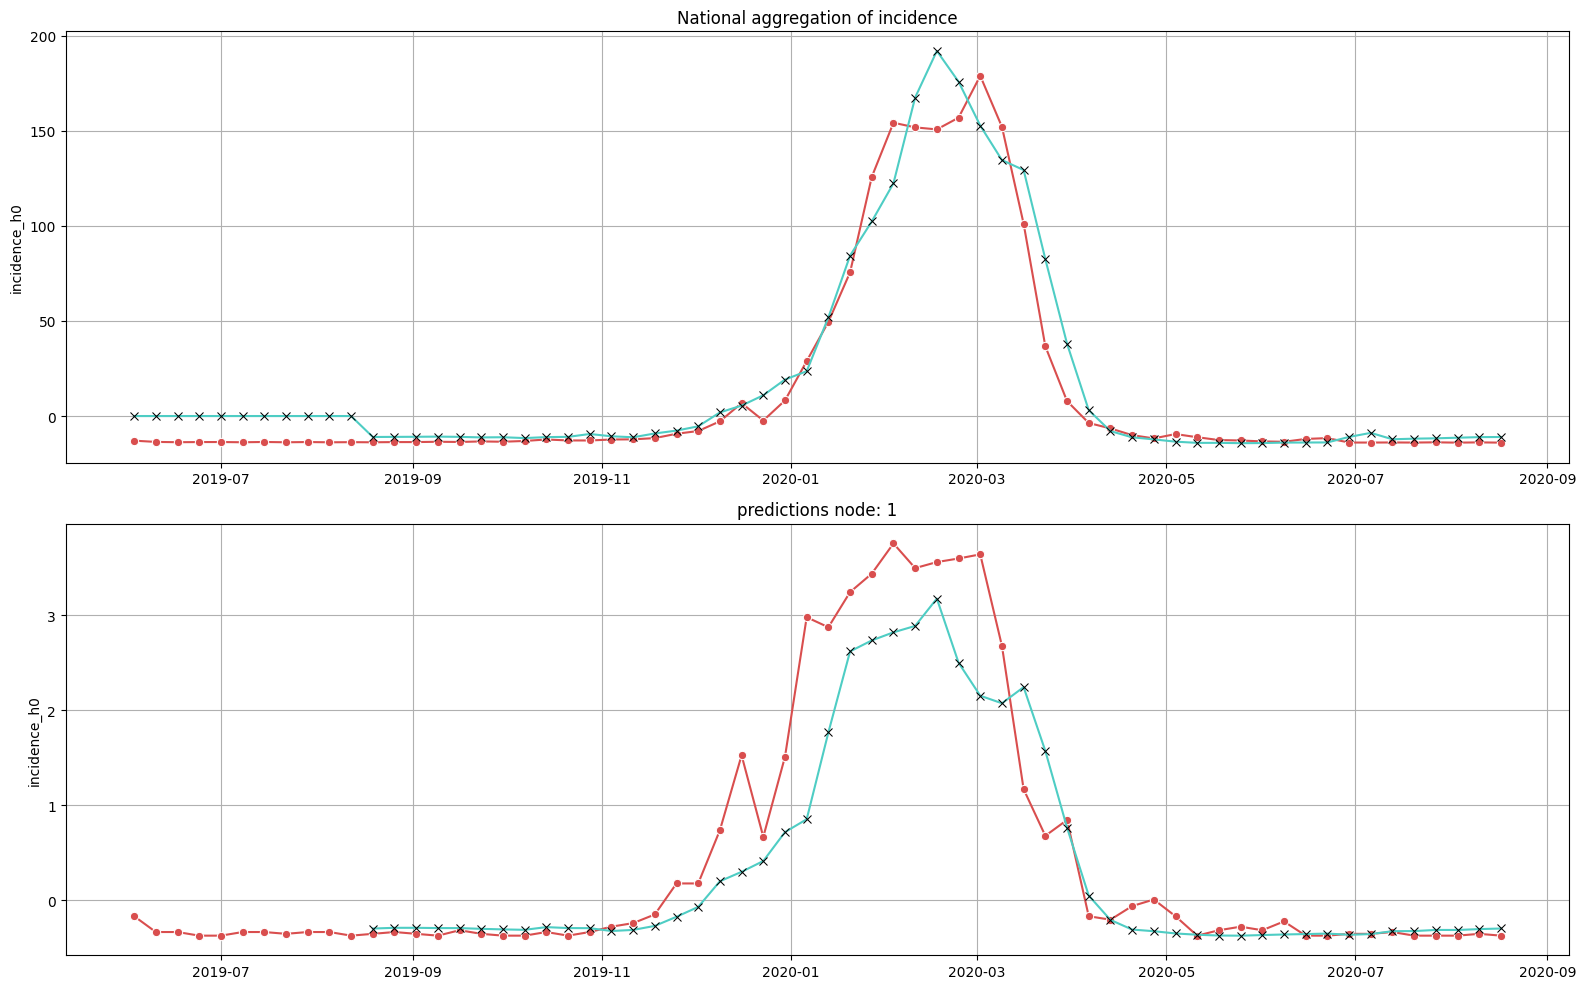

In [4]:
n_epochs = 100
lr       = 0.0001

ml1_id = SpatialGCNModel(name = f'spatial gcn - identity graph', dataloader=epidata_nuts2_id)
ml1_id.set_model_hparams()
ml1_id.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml1_id.run_snapshot(debug=True)
ml1_id.train(verbose=2)
ml1_id.forecast()
ml1_id.show_forecasts(dataset='test', target_h = 0)

ml1_bn = SpatialGCNModel(name = f'spatial gcn - boolean neighbors', dataloader=epidata_nuts2_bn)
ml1_bn.set_model_hparams()
ml1_bn.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml1_bn.run_snapshot(debug=True)
ml1_bn.train(verbose=2)
ml1_bn.forecast()
ml1_bn.show_forecasts(dataset='test', target_h = 0)

ml1_gm1 = SpatialGCNModel(name = f'spatial gcn - gravity model1', dataloader=epidata_nuts2_gm1)
ml1_gm1.set_model_hparams()
ml1_gm1.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml1_gm1.run_snapshot(debug=True)
ml1_gm1.train(verbose=2)
ml1_gm1.forecast()
ml1_gm1.show_forecasts(dataset='test', target_h = 0)

ml1_gm2 = SpatialGCNModel(name = f'spatial gcn - gravity model2', dataloader=epidata_nuts2_gm2)
ml1_gm2.set_model_hparams()
ml1_gm2.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml1_gm2.run_snapshot(debug=True)
ml1_gm2.train(verbose=2)
ml1_gm2.forecast()
ml1_gm2.show_forecasts(dataset='test', target_h = 0)

shape x: torch.Size([38, 4, 12])
shape unsqueezed x: torch.Size([1, 38, 4, 12])
shape h: torch.Size([1, 38, 32])
shape output: torch.Size([38, 4])

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: <src.dataloading.graphdataloader.GraphDataLoaderEntry object at 0x7f2d88981310>
Epoch 1 train loss: 0.7761, val loss: 1.4257 ✓ (new best)
Epoch 2 train loss: 0.7269, val loss: 1.3015 ✓ (new best)
Epoch 3 train loss: 0.6625, val loss: 1.1404 ✓ (new best)
Epoch 4 train loss: 0.6091, val loss: 1.0176 ✓ (new best)
Epoch 5 train loss: 0.5684, val loss: 0.9156 ✓ (new best)
Epoch 6 train loss: 0.5411, val loss: 0.8553 ✓ (new best)
Epoch 7 train loss: 0.5197, val loss: 0.8143 ✓ (new best)
Epoch 8 train loss: 0.5028, val loss: 0.7857 ✓ (new best)
Epoch 9 train loss: 0.4916, val loss: 0.7505 ✓ (new best)
Epoch 10 train loss: 0.4813, val loss: 0.7387 ✓ (new best)
Epoch 11 train loss: 0.4

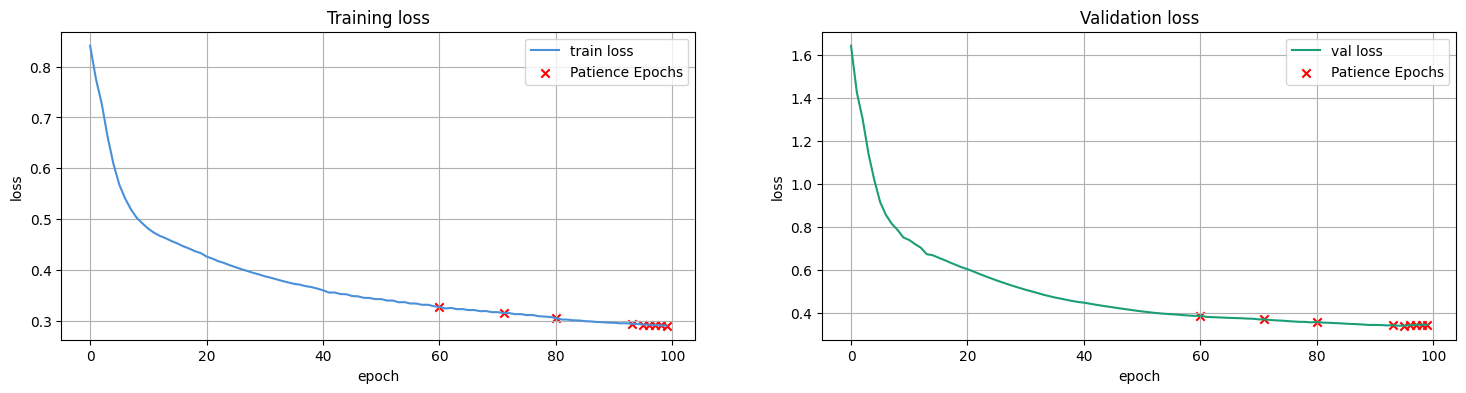

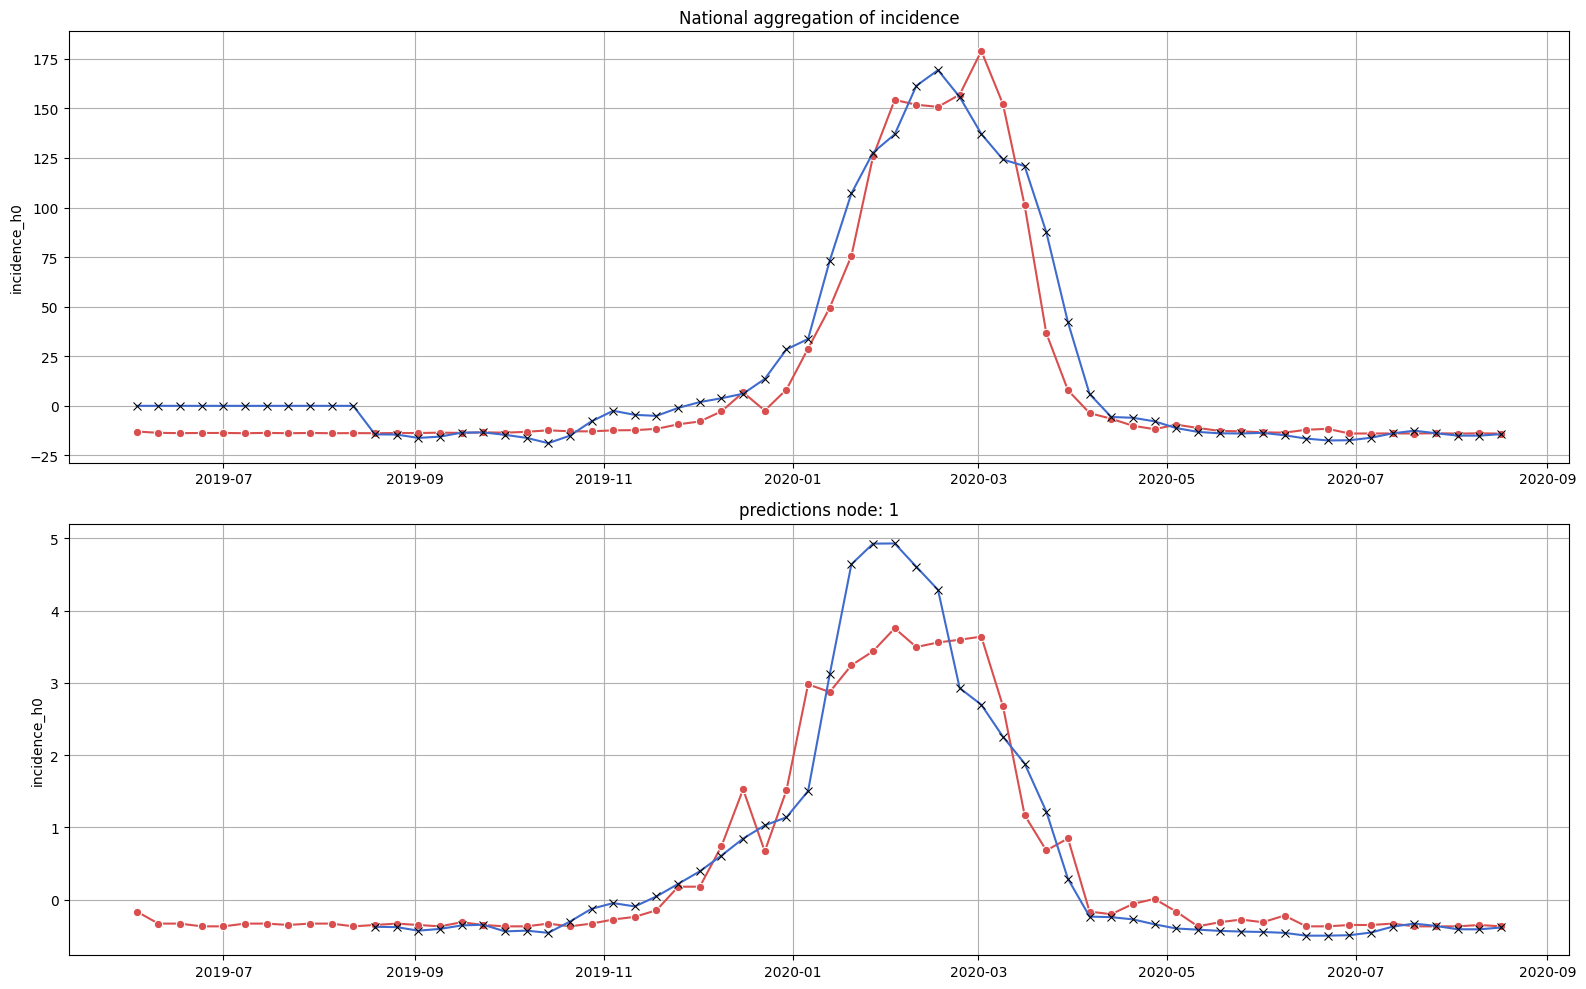

shape x: torch.Size([38, 4, 12])
shape unsqueezed x: torch.Size([1, 38, 4, 12])
shape h: torch.Size([1, 38, 32])
shape output: torch.Size([38, 4])

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: <src.dataloading.graphdataloader.GraphDataLoaderEntry object at 0x7f2d88dee890>
Epoch 1 train loss: 0.7976, val loss: 1.3730 ✓ (new best)
Epoch 2 train loss: 0.7533, val loss: 1.2585 ✓ (new best)
Epoch 3 train loss: 0.6986, val loss: 1.1397 ✓ (new best)
Epoch 4 train loss: 0.6480, val loss: 1.0300 ✓ (new best)
Epoch 5 train loss: 0.6063, val loss: 0.9359 ✓ (new best)
Epoch 6 train loss: 0.5797, val loss: 0.8708 ✓ (new best)
Epoch 7 train loss: 0.5546, val loss: 0.8227 ✓ (new best)
Epoch 8 train loss: 0.5358, val loss: 0.7871 ✓ (new best)
Epoch 9 train loss: 0.5204, val loss: 0.7606 ✓ (new best)
Epoch 10 train loss: 0.5072, val loss: 0.7386 ✓ (new best)
Epoch 11 train loss: 0.4

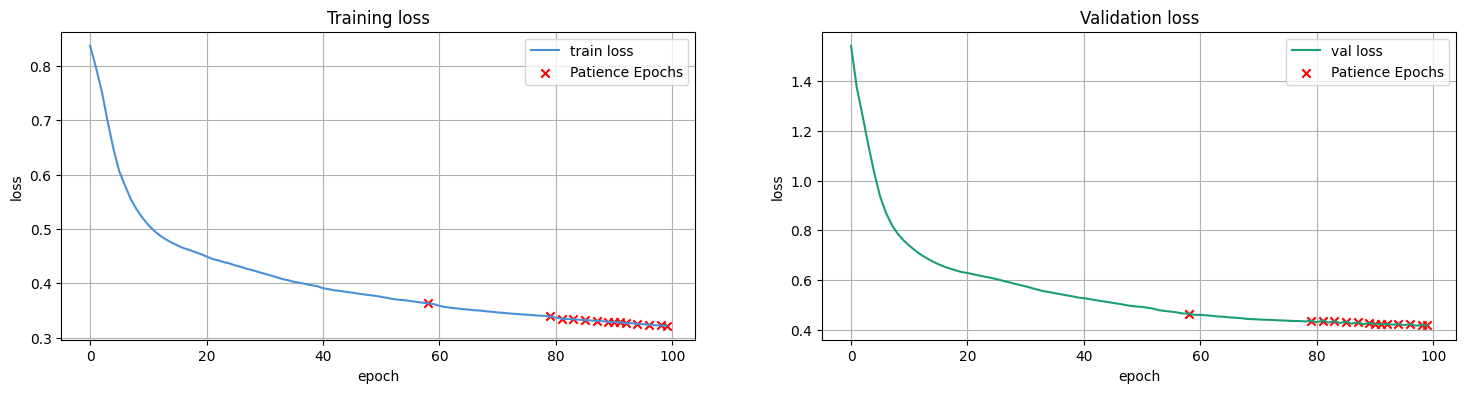

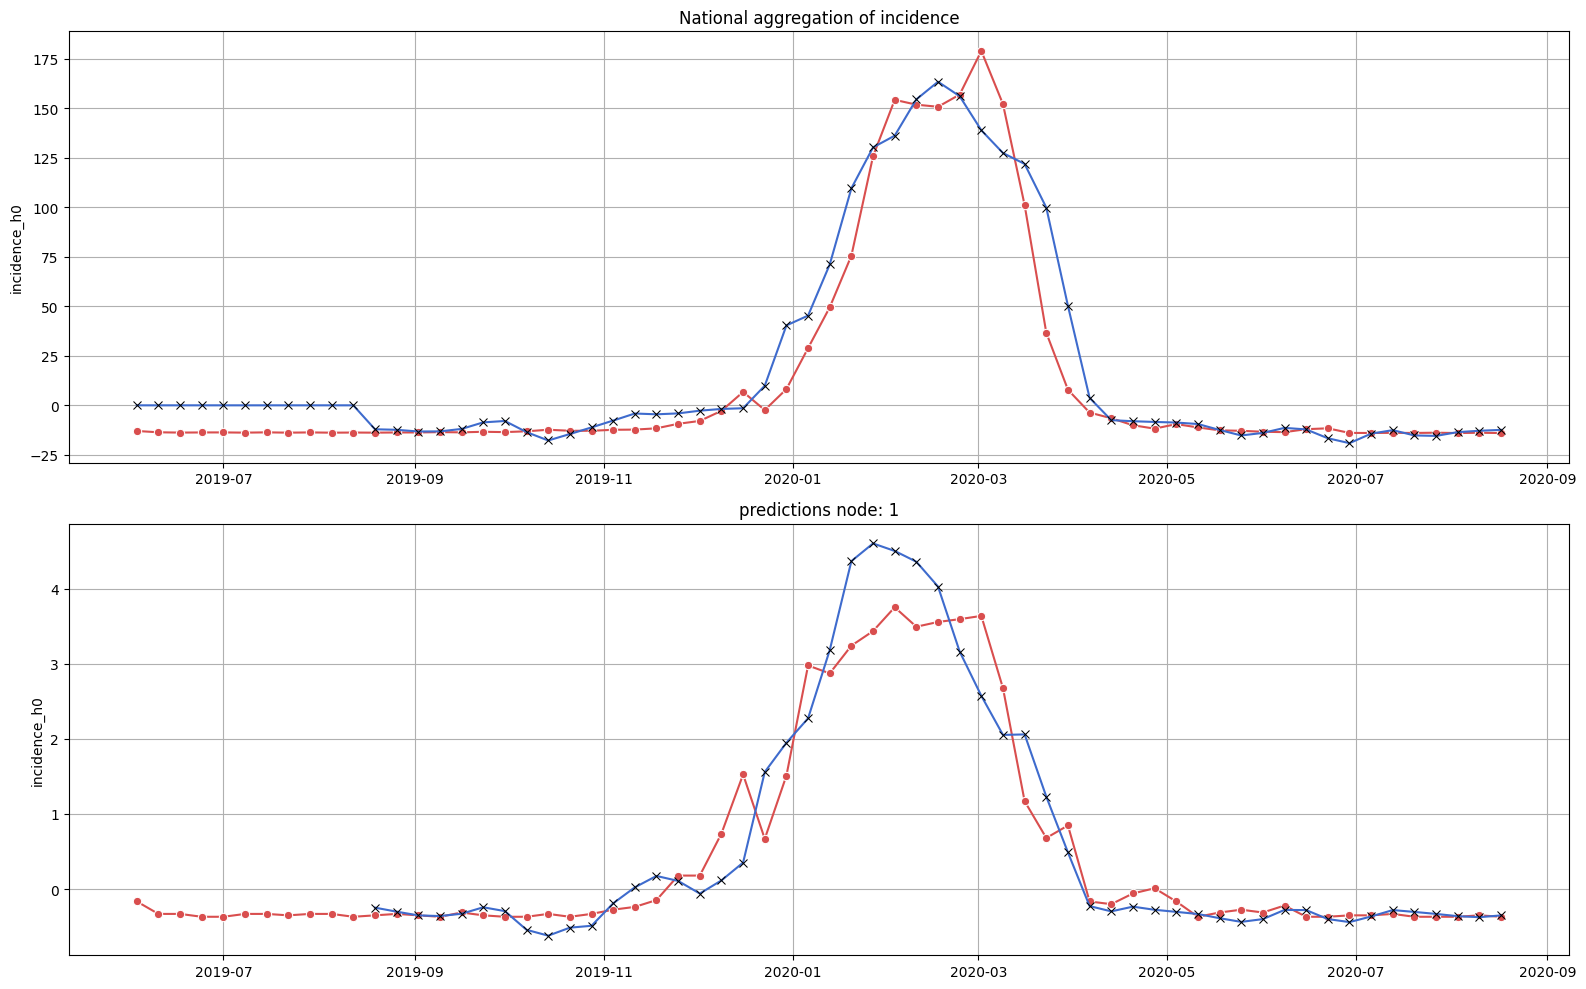

shape x: torch.Size([38, 4, 12])
shape unsqueezed x: torch.Size([1, 38, 4, 12])
shape h: torch.Size([1, 38, 32])
shape output: torch.Size([38, 4])

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: <src.dataloading.graphdataloader.GraphDataLoaderEntry object at 0x7f2d886de250>
Epoch 1 train loss: 0.7968, val loss: 1.4185 ✓ (new best)
Epoch 2 train loss: 0.7353, val loss: 1.2438 ✓ (new best)
Epoch 3 train loss: 0.6814, val loss: 1.1112 ✓ (new best)
Epoch 4 train loss: 0.6401, val loss: 1.0195 ✓ (new best)
Epoch 5 train loss: 0.6092, val loss: 0.9534 ✓ (new best)
Epoch 6 train loss: 0.5843, val loss: 0.9087 ✓ (new best)
Epoch 7 train loss: 0.5631, val loss: 0.8694 ✓ (new best)
Epoch 8 train loss: 0.5482, val loss: 0.8380 ✓ (new best)
Epoch 9 train loss: 0.5324, val loss: 0.8170 ✓ (new best)
Epoch 10 train loss: 0.5206, val loss: 0.7898 ✓ (new best)
Epoch 11 train loss: 0.5

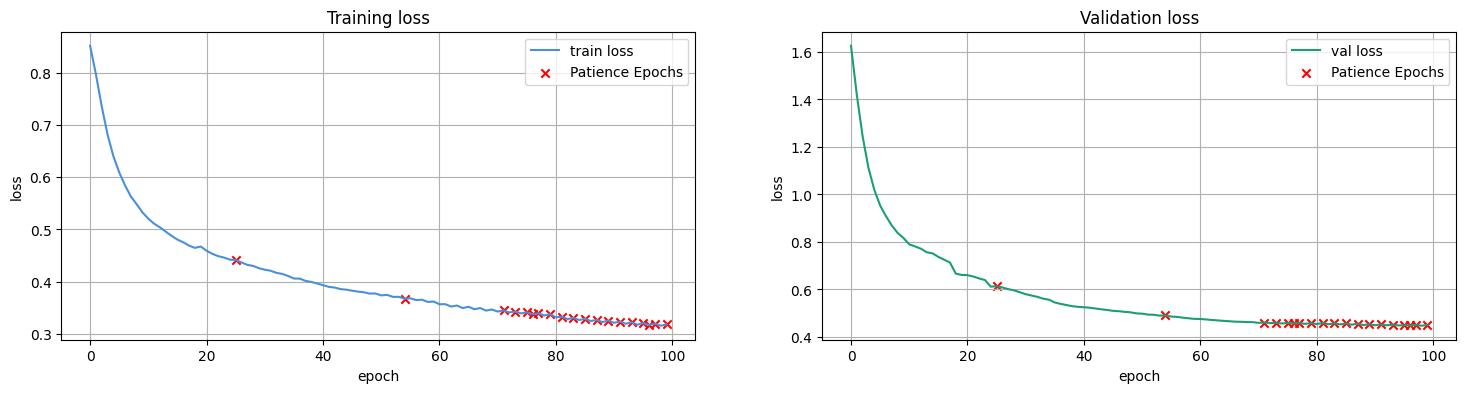

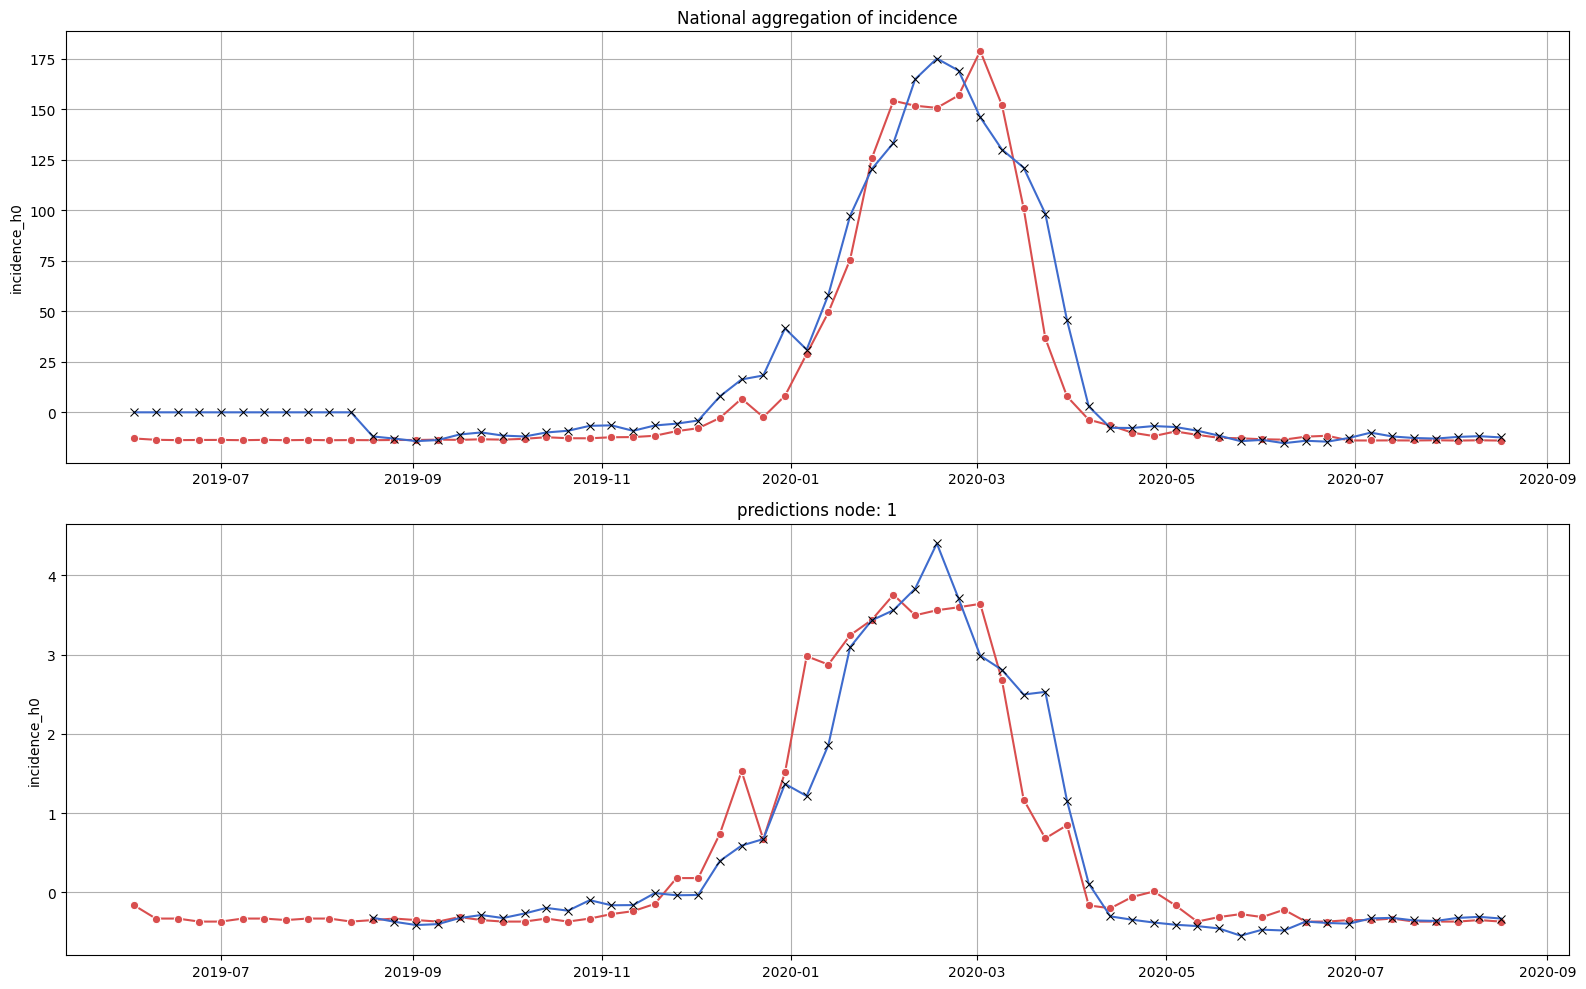

shape x: torch.Size([38, 4, 12])
shape unsqueezed x: torch.Size([1, 38, 4, 12])
shape h: torch.Size([1, 38, 32])
shape output: torch.Size([38, 4])

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: <src.dataloading.graphdataloader.GraphDataLoaderEntry object at 0x7f2d88c49d10>
Epoch 1 train loss: 0.7891, val loss: 1.4257 ✓ (new best)
Epoch 2 train loss: 0.7363, val loss: 1.2766 ✓ (new best)
Epoch 3 train loss: 0.6755, val loss: 1.1325 ✓ (new best)
Epoch 4 train loss: 0.6315, val loss: 1.0189 ✓ (new best)
Epoch 5 train loss: 0.5949, val loss: 0.9358 ✓ (new best)
Epoch 6 train loss: 0.5666, val loss: 0.8791 ✓ (new best)
Epoch 7 train loss: 0.5408, val loss: 0.8340 ✓ (new best)
Epoch 8 train loss: 0.5213, val loss: 0.7993 ✓ (new best)
Epoch 9 train loss: 0.5061, val loss: 0.7743 ✓ (new best)
Epoch 10 train loss: 0.4948, val loss: 0.7520 ✓ (new best)
Epoch 11 train loss: 0.4

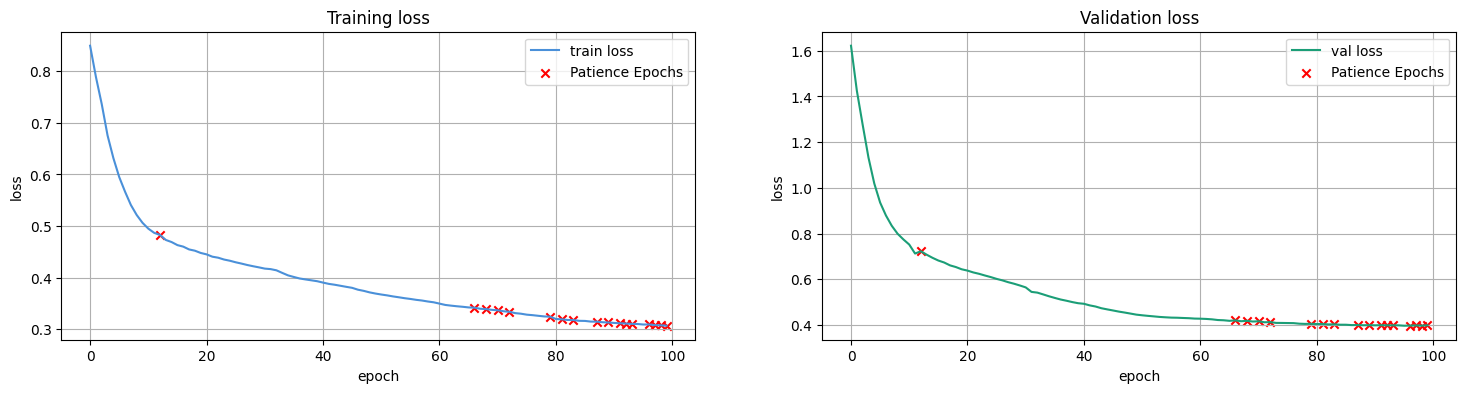

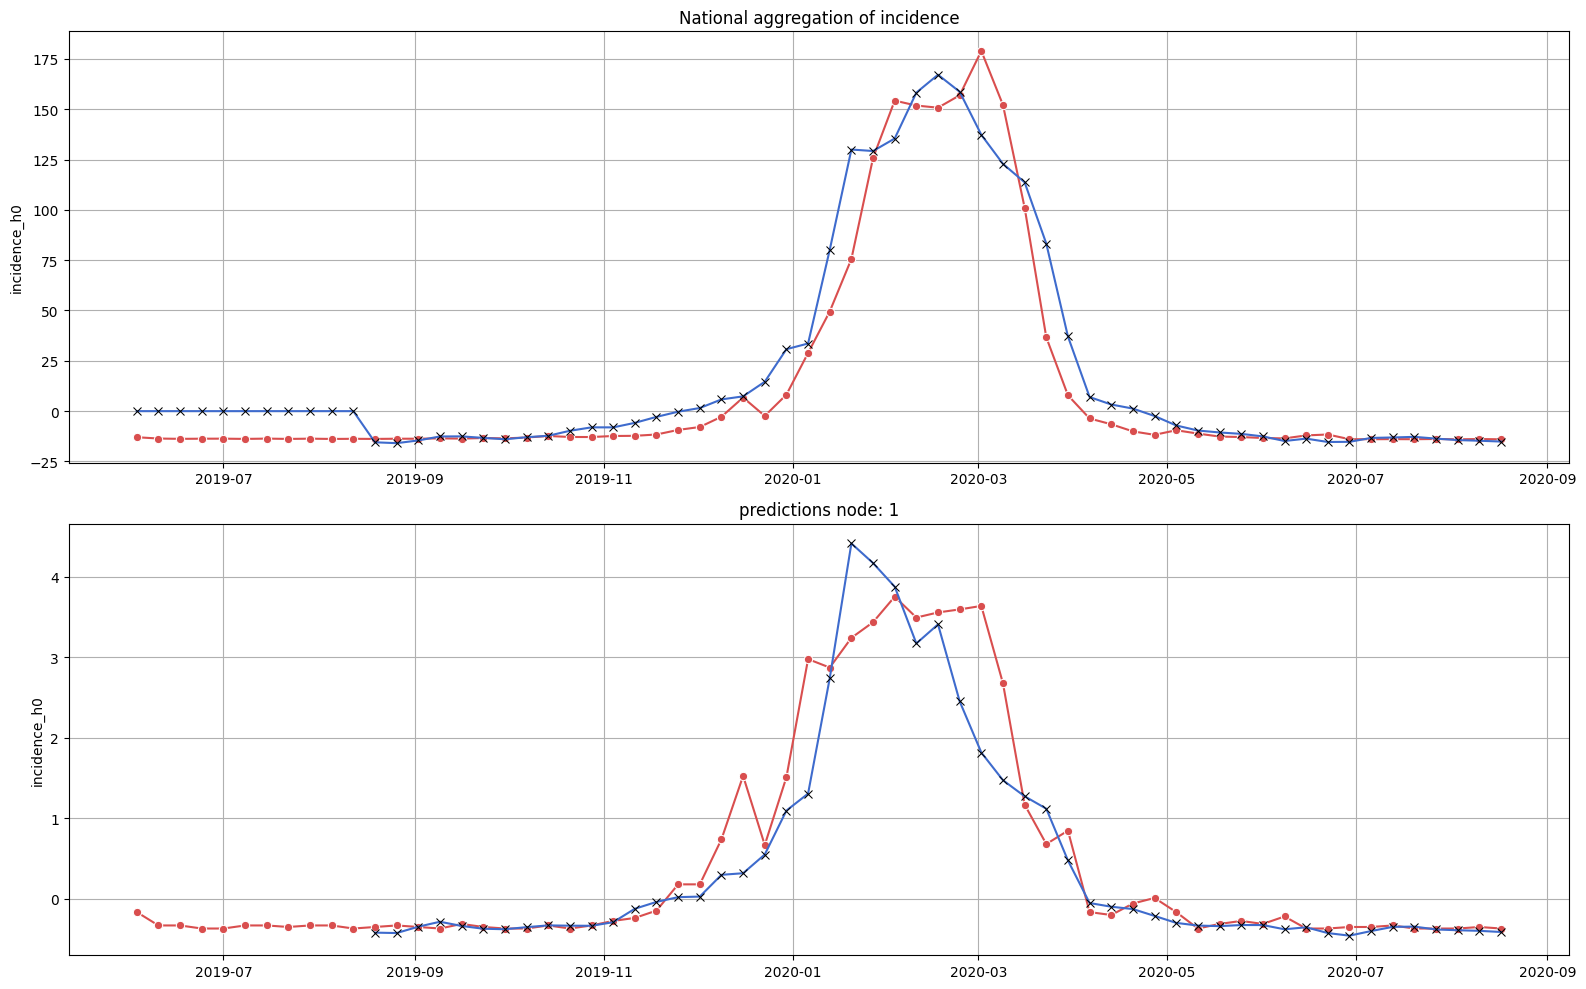

In [5]:
n_epochs = 100
lr       = 0.001

ml2_id = A3TGCNModel(name = f'A3TGCN - identity graph', dataloader=epidata_nuts2_id)
ml2_id.set_model_hparams()
ml2_id.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml2_id.run_snapshot(debug=True)
ml2_id.train(verbose=2)
ml2_id.forecast()
ml2_id.show_forecasts(dataset='test', target_h = 0)

ml2_bn = A3TGCNModel(name = f'A3TGCN - boolean neighbors', dataloader=epidata_nuts2_bn)
ml2_bn.set_model_hparams()
ml2_bn.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml2_bn.run_snapshot(debug=True)
ml2_bn.train(verbose=2)
ml2_bn.forecast()
ml2_bn.show_forecasts(dataset='test', target_h = 0)

ml2_gm1 = A3TGCNModel(name = f'A3TGCN - gravity model1', dataloader=epidata_nuts2_gm1)
ml2_gm1.set_model_hparams()
ml2_gm1.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml2_gm1.run_snapshot(debug=True)
ml2_gm1.train(verbose=2)
ml2_gm1.forecast()
ml2_gm1.show_forecasts(dataset='test', target_h = 0)

ml2_gm2 = A3TGCNModel(name = f'A3TGCN - gravity model2', dataloader=epidata_nuts2_gm2)
ml2_gm2.set_model_hparams()
ml2_gm2.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml2_gm2.run_snapshot(debug=True)
ml2_gm2.train(verbose=2)
ml2_gm2.forecast()
ml2_gm2.show_forecasts(dataset='test', target_h = 0)

# Measles

In [30]:
epidata_nuts1 = GNNDataLoader('measles', data_env, nuts_level='nuts1', min_date='2006-01-15',max_date='2017-06-01', include_population=True, periods = 12, prediction_horizon=4)
epidata_nuts1.add_time_features()
epidata_nuts1.log_transform_target()
epidata_nuts1.set_splits(split_trainval='2014-06-01',split_valtest='2015-08-01')
epidata_nuts1.normalize()
epidata_nuts1.add_lagged_features(lags = range(2,3))
epidata_nuts1.finalize()

epidata_nuts1_id  = epidata_nuts1.copy(deep=True).retrieve_graph(graphname = 'identity_graph').construct_dataloaders()
epidata_nuts1_bn  = epidata_nuts1.copy(deep=True).retrieve_graph(graphname = 'boolean_neighbors_self0').construct_dataloaders()
epidata_nuts1_gm1 = epidata_nuts1.copy(deep=True).retrieve_graph(graphname = 'gravity_model_dense').construct_dataloaders()
epidata_nuts1_gm2 = epidata_nuts1.copy(deep=True).retrieve_graph(graphname = 'gravity_model_sparse').construct_dataloaders()

GNN temporal windowing: extending data collection from 2017-06-01 to 2017-09-14 (+15 weeks)
GNN temporal windowing: extending data collection from 2017-06-01 to 2017-09-14 (+15 weeks)
GNN temporal windowing: extending data collection from 2017-06-01 to 2017-09-14 (+15 weeks)
GNN temporal windowing: extending data collection from 2017-06-01 to 2017-09-14 (+15 weeks)
GNN temporal windowing: extending data collection from 2017-06-01 to 2017-09-14 (+15 weeks)


shape x: torch.Size([16, 4, 12])
shape unsqueezed x: torch.Size([1, 16, 4, 12])
shape h: torch.Size([1, 16, 32])
shape output: torch.Size([16, 4])

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([16, 4])
➡️  Ground truth shape: torch.Size([16, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: <src.dataloading.graphdataloader.GraphDataLoaderEntry object at 0x7f2d12eb1110>
Epoch 1 train loss: 0.7621, val loss: 9.0349 ✓ (new best)
Epoch 2 train loss: 0.7112, val loss: 8.5031 ✓ (new best)
Epoch 3 train loss: 0.6671, val loss: 8.0171 ✓ (new best)
Epoch 4 train loss: 0.6330, val loss: 7.6377 ✓ (new best)
Epoch 5 train loss: 0.6127, val loss: 7.3697 ✓ (new best)
Epoch 6 train loss: 0.5983, val loss: 7.1962 ✓ (new best)
Epoch 7 train loss: 0.5826, val loss: 7.0443 ✓ (new best)
Epoch 8 train loss: 0.5680, val loss: 6.9076 ✓ (new best)
Epoch 9 train loss: 0.5711, val loss: 6.8260 ✓ (new best)
Epoch 10 train loss: 0.5757, val loss: 6.7530 ✓ (new best)
Epoch 11 train loss: 0.5

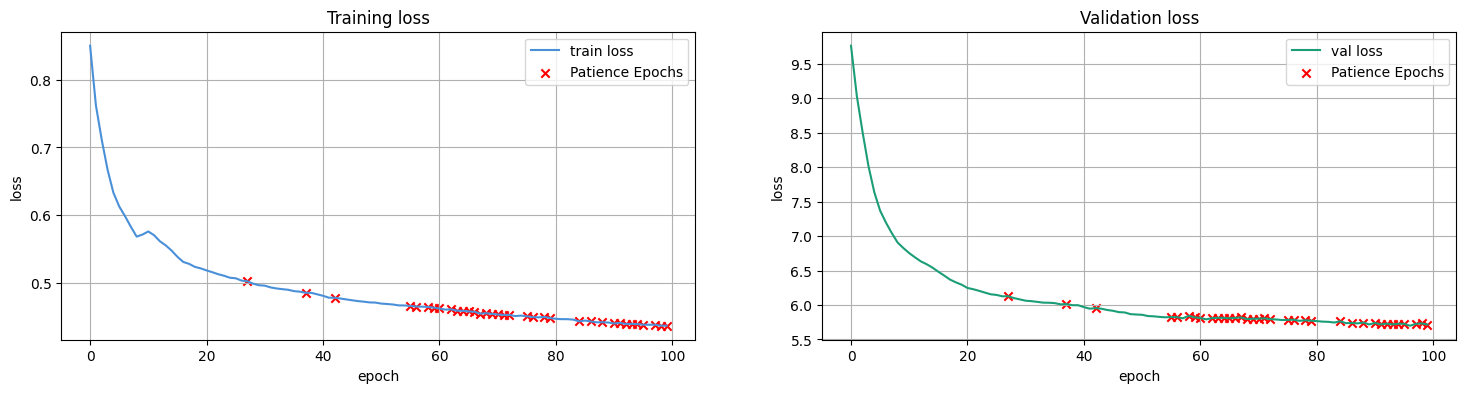

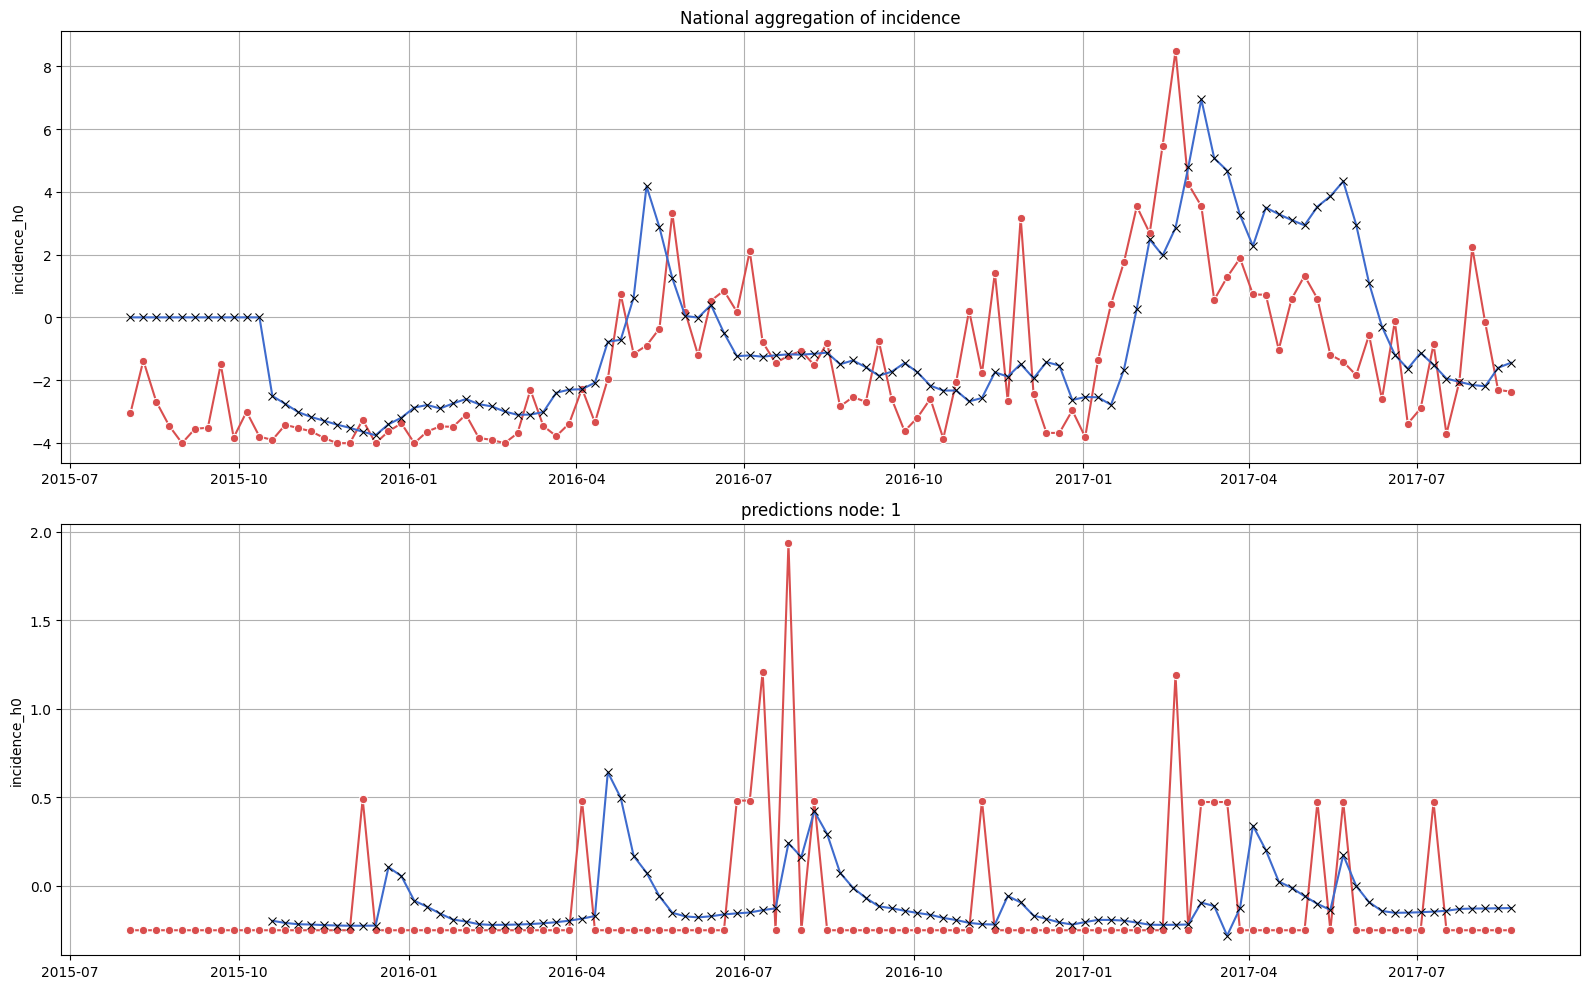

shape x: torch.Size([16, 4, 12])
shape unsqueezed x: torch.Size([1, 16, 4, 12])
shape h: torch.Size([1, 16, 32])
shape output: torch.Size([16, 4])

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([16, 4])
➡️  Ground truth shape: torch.Size([16, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: <src.dataloading.graphdataloader.GraphDataLoaderEntry object at 0x7f2d13609d50>
Epoch 1 train loss: 0.8064, val loss: 9.2958 ✓ (new best)
Epoch 2 train loss: 0.7738, val loss: 8.8366 ✓ (new best)
Epoch 3 train loss: 0.7474, val loss: 8.4761 ✓ (new best)
Epoch 4 train loss: 0.7275, val loss: 8.2366 ✓ (new best)
Epoch 5 train loss: 0.7157, val loss: 8.0608 ✓ (new best)
Epoch 6 train loss: 0.7103, val loss: 7.9168 ✓ (new best)
Epoch 7 train loss: 0.7021, val loss: 7.7884 ✓ (new best)
Epoch 8 train loss: 0.6907, val loss: 7.6635 ✓ (new best)
Epoch 9 train loss: 0.6829, val loss: 7.5960 ✓ (new best)
Epoch 10 train loss: 0.6746, val loss: 7.4837 ✓ (new best)
Epoch 11 train loss: 0.6

KeyboardInterrupt: 

In [31]:
n_epochs = 100
lr       = 0.001

ml2_id = A3TGCNModel(name = f'A3TGCN - identity graph', dataloader=epidata_nuts1_id)
ml2_id.set_model_hparams()
ml2_id.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml2_id.run_snapshot(debug=True)
ml2_id.train(verbose=2)
ml2_id.forecast()
ml2_id.show_forecasts(dataset='test', target_h = 0)

ml2_bn = A3TGCNModel(name = f'A3TGCN - boolean neighbors', dataloader=epidata_nuts1_bn)
ml2_bn.set_model_hparams()
ml2_bn.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml2_bn.run_snapshot(debug=True)
ml2_bn.train(verbose=2)
ml2_bn.forecast()
ml2_bn.show_forecasts(dataset='test', target_h = 0)

ml2_gm1 = A3TGCNModel(name = f'A3TGCN - gravity model1', dataloader=epidata_nuts1_gm1)
ml2_gm1.set_model_hparams()
ml2_gm1.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml2_gm1.run_snapshot(debug=True)
ml2_gm1.train(verbose=2)
ml2_gm1.forecast()
ml2_gm1.show_forecasts(dataset='test', target_h = 0)

ml2_gm2 = A3TGCNModel(name = f'A3TGCN - gravity model2', dataloader=epidata_nuts1_gm2)
ml2_gm2.set_model_hparams()
ml2_gm2.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml2_gm2.run_snapshot(debug=True)
ml2_gm2.train(verbose=2)
ml2_gm2.forecast()
ml2_gm2.show_forecasts(dataset='test', target_h = 0)

GNN temporal windowing: extending data collection from 2017-06-01 to 2017-09-14 (+15 weeks)
GNN temporal windowing: extending data collection from 2017-06-01 to 2017-09-14 (+15 weeks)
GNN temporal windowing: extending data collection from 2017-06-01 to 2017-09-14 (+15 weeks)
GNN temporal windowing: extending data collection from 2017-06-01 to 2017-09-14 (+15 weeks)
GNN temporal windowing: extending data collection from 2017-06-01 to 2017-09-14 (+15 weeks)
⚠️  Input features are 3D (e.g., sequences). Only the last dimension will be used (flattened).

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: <src.dataloading.graphdataloader.GraphDataLoaderEntry object at 0x7f2d851ada50>
Epoch 1 train loss: 0.5251, val loss: 2.1768 ✓ (new best)
Epoch 2 train loss: 0.4980, val loss: 2.0955 ✓ (new best)
Epoch 3 train loss: 0.4926, val loss: 2.0570 ✓ (new best)
Epoch 4 train loss: 0.4

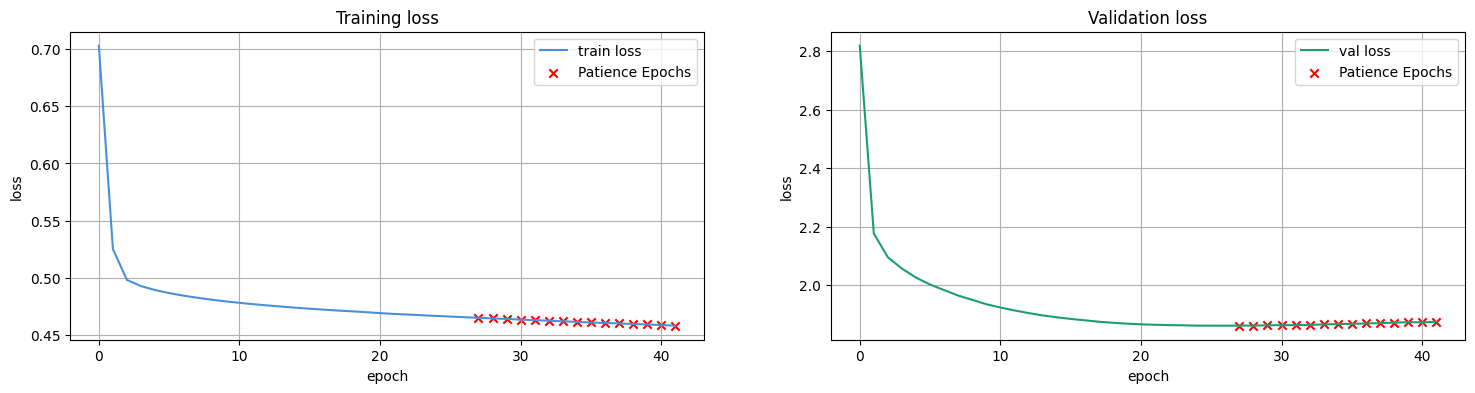

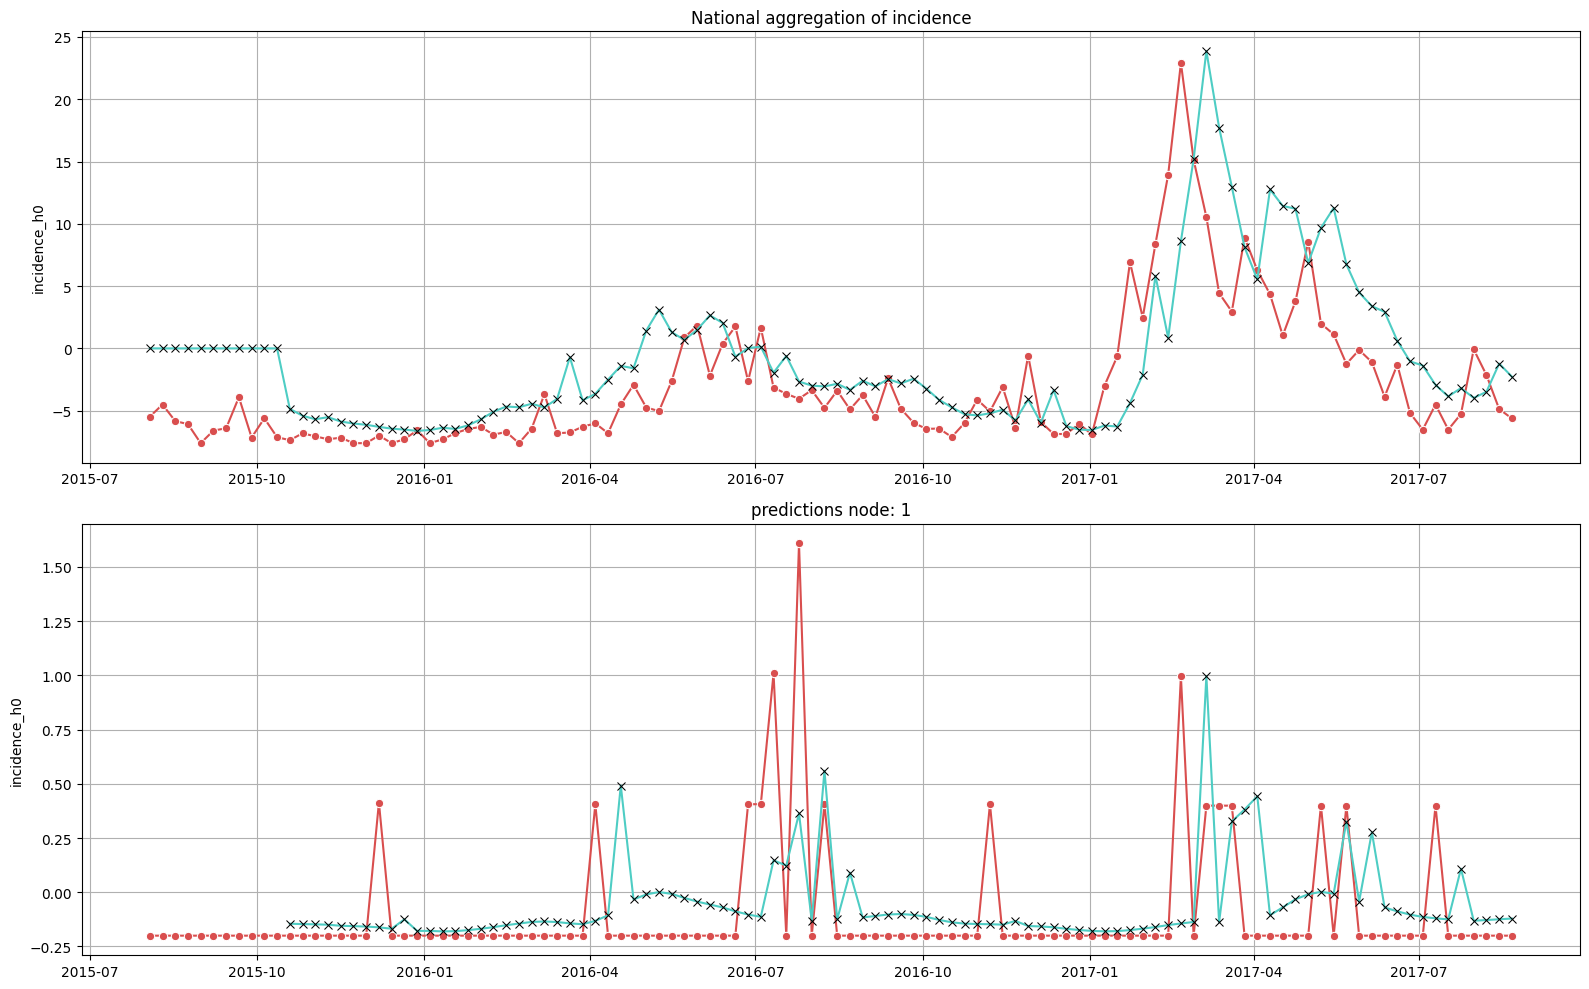

⚠️  Input features are 3D (e.g., sequences). Only the last dimension will be used (flattened).

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: <src.dataloading.graphdataloader.GraphDataLoaderEntry object at 0x7f2d603322d0>
Epoch 1 train loss: 0.6453, val loss: 2.0747 ✓ (new best)
Epoch 2 train loss: 0.6155, val loss: 1.9779 ✓ (new best)
Epoch 3 train loss: 0.6101, val loss: 1.9461 ✓ (new best)
Epoch 4 train loss: 0.6070, val loss: 1.9270 ✓ (new best)
Epoch 5 train loss: 0.6045, val loss: 1.9128 ✓ (new best)
Epoch 6 train loss: 0.6023, val loss: 1.9014 ✓ (new best)
Epoch 7 train loss: 0.6001, val loss: 1.8916 ✓ (new best)
Epoch 8 train loss: 0.5980, val loss: 1.8835 ✓ (new best)
Epoch 9 train loss: 0.5958, val loss: 1.8751 ✓ (new best)
Epoch 10 train loss: 0.5937, val loss: 1.8676 ✓ (new best)
Epoch 11 train loss: 0.5915, val loss: 1.8609 ✓ (new best)
Epoch 12 train lo

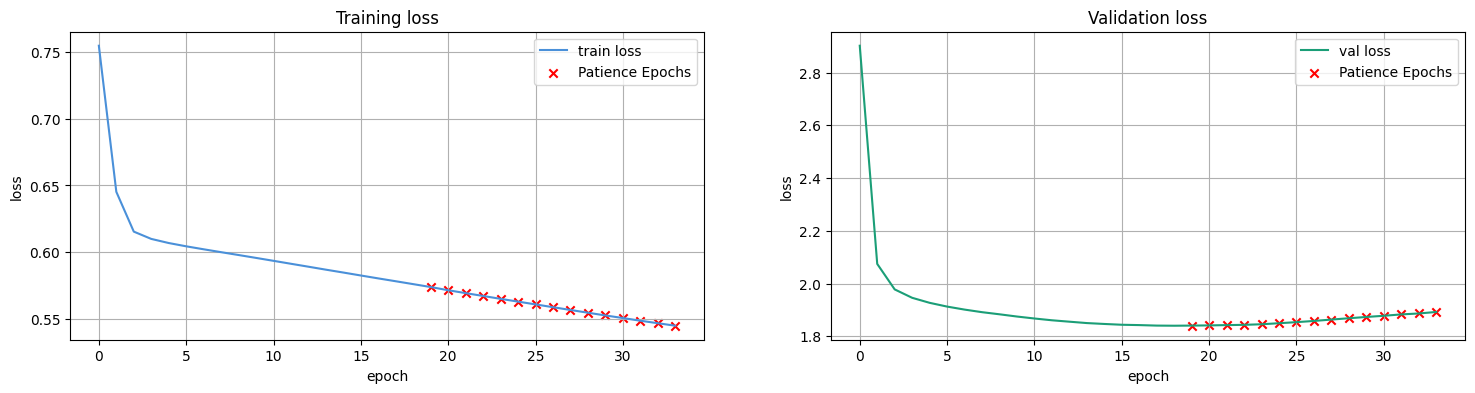

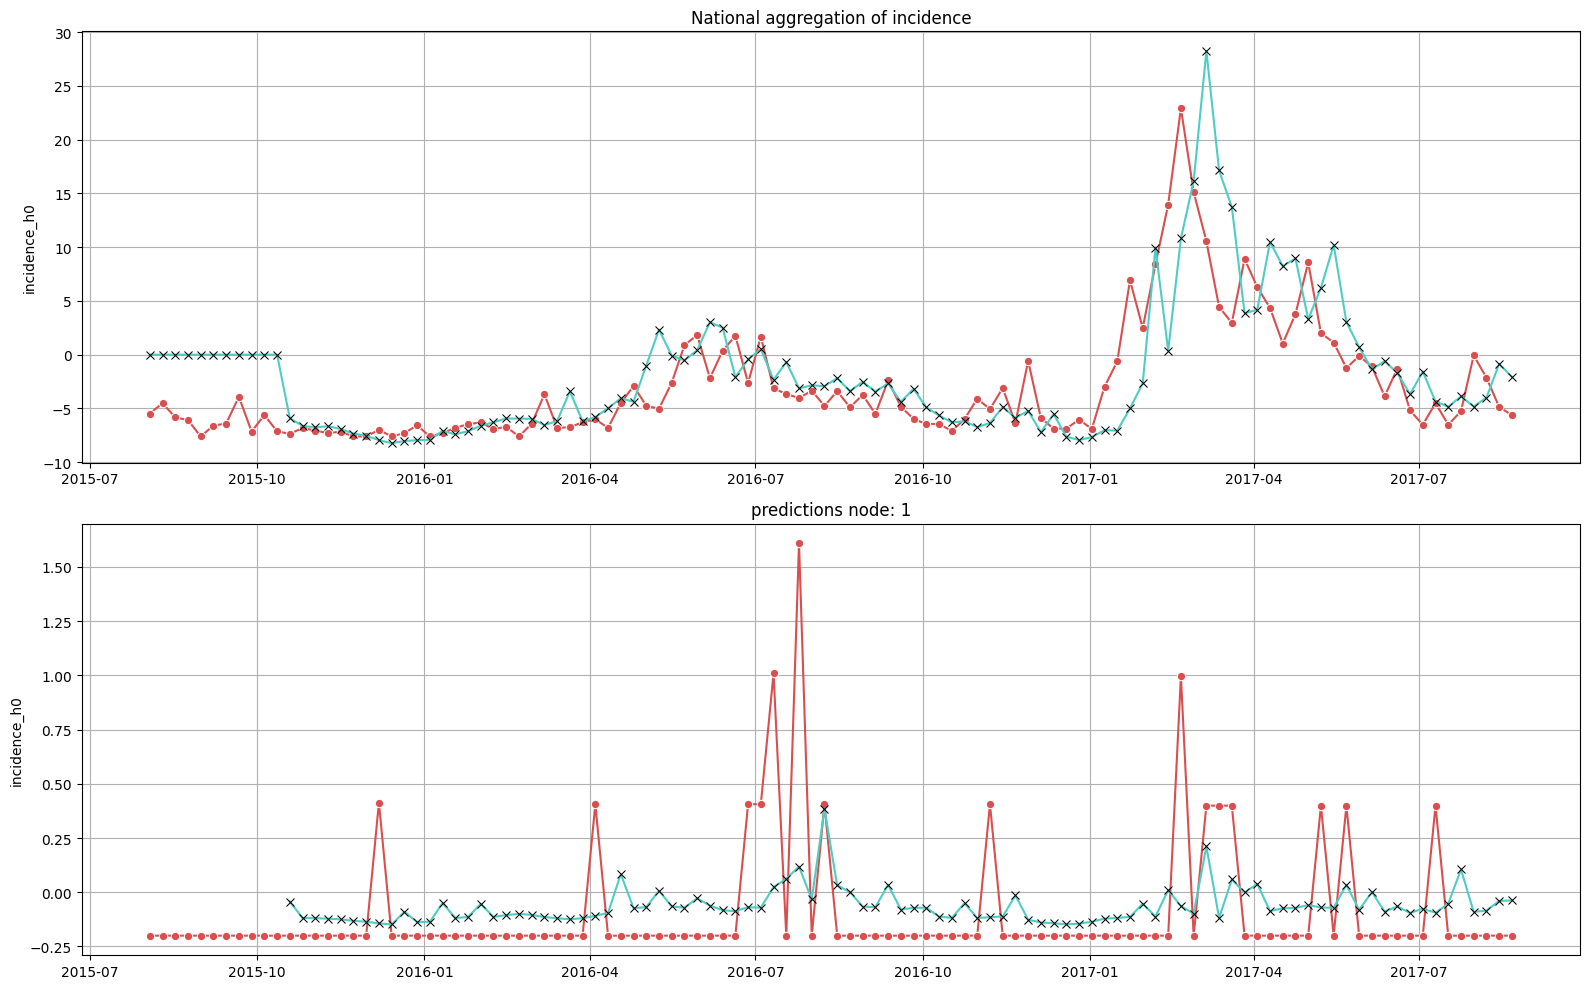

⚠️  Input features are 3D (e.g., sequences). Only the last dimension will be used (flattened).

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: <src.dataloading.graphdataloader.GraphDataLoaderEntry object at 0x7f2d12858790>
Epoch 1 train loss: 0.7618, val loss: 3.9767 ✓ (new best)
Epoch 2 train loss: 0.7411, val loss: 3.8656 ✓ (new best)
Epoch 3 train loss: 0.7331, val loss: 3.8208 ✓ (new best)
Epoch 4 train loss: 0.7307, val loss: 3.8002 ✓ (new best)
Epoch 5 train loss: 0.7294, val loss: 3.7873 ✓ (new best)
Epoch 6 train loss: 0.7285, val loss: 3.7787 ✓ (new best)
Epoch 7 train loss: 0.7278, val loss: 3.7720 ✓ (new best)
Epoch 8 train loss: 0.7272, val loss: 3.7667 ✓ (new best)
Epoch 9 train loss: 0.7267, val loss: 3.7623 ✓ (new best)
Epoch 10 train loss: 0.7263, val loss: 3.7589 ✓ (new best)
Epoch 11 train loss: 0.7259, val loss: 3.7552 ✓ (new best)
Epoch 12 train lo

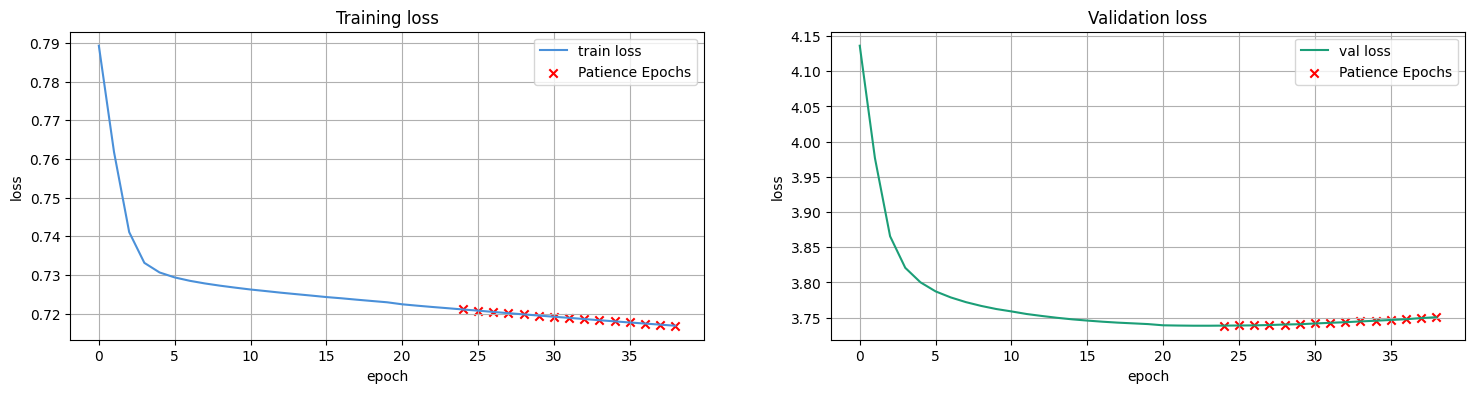

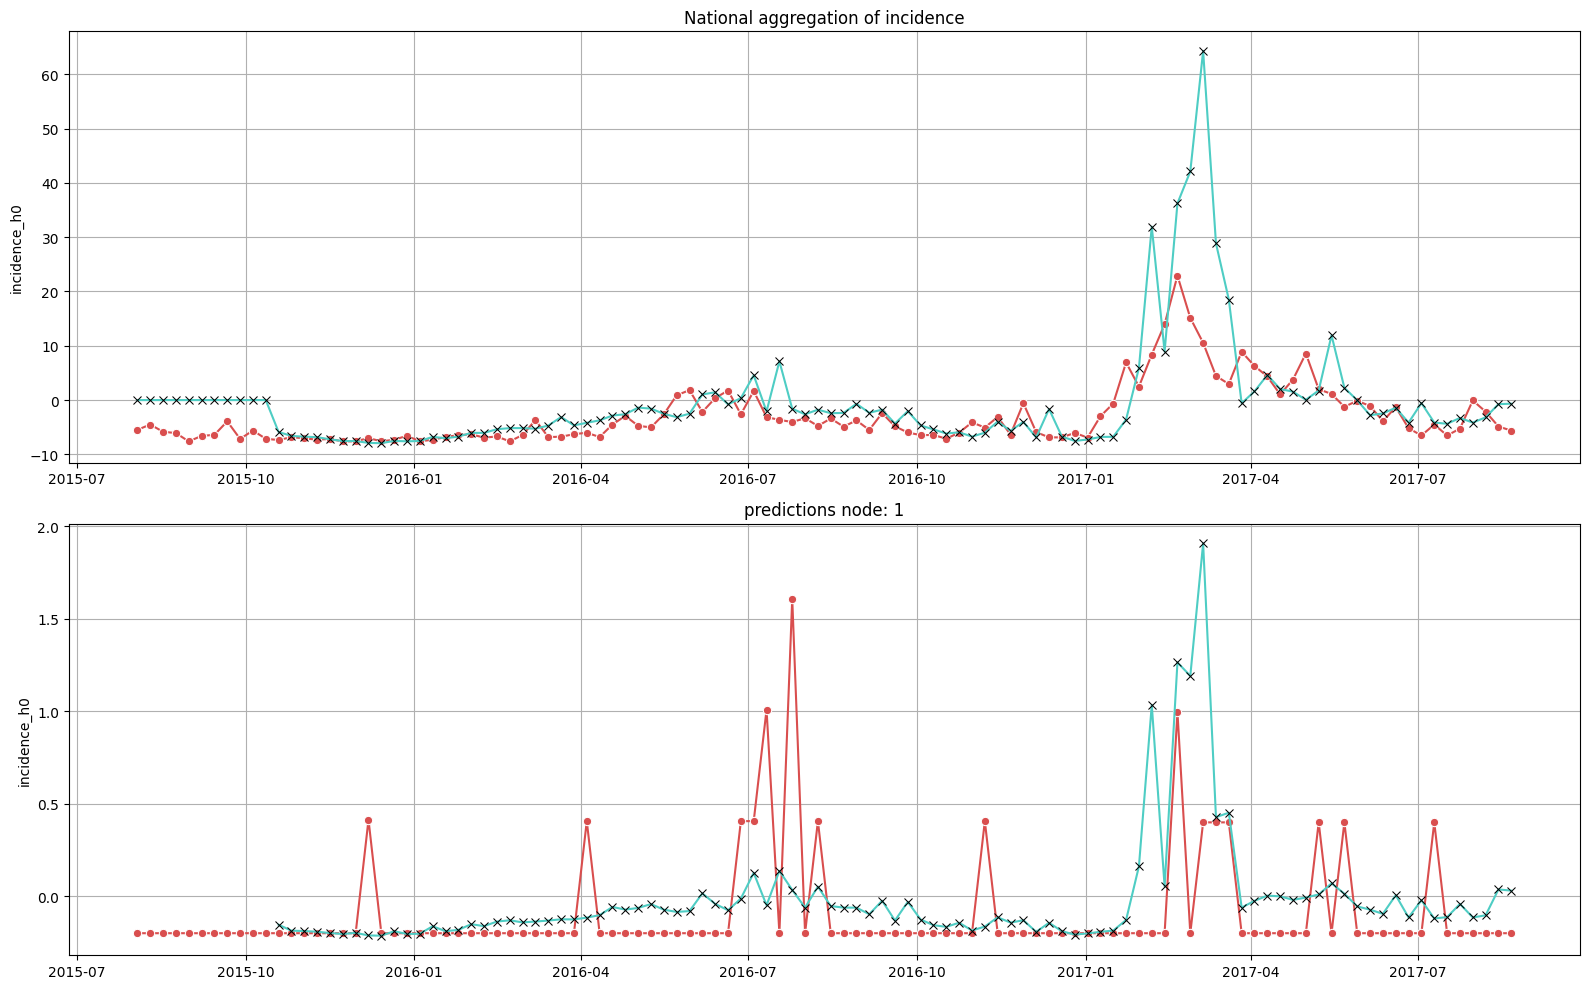

⚠️  Input features are 3D (e.g., sequences). Only the last dimension will be used (flattened).

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: <src.dataloading.graphdataloader.GraphDataLoaderEntry object at 0x7f2d122cdb90>
Epoch 1 train loss: 0.7037, val loss: 3.0544 ✓ (new best)
Epoch 2 train loss: 0.6856, val loss: 2.9414 ✓ (new best)
Epoch 3 train loss: 0.6809, val loss: 2.8978 ✓ (new best)
Epoch 4 train loss: 0.6782, val loss: 2.8702 ✓ (new best)
Epoch 5 train loss: 0.6760, val loss: 2.8495 ✓ (new best)
Epoch 6 train loss: 0.6738, val loss: 2.8338 ✓ (new best)
Epoch 7 train loss: 0.6716, val loss: 2.8206 ✓ (new best)
Epoch 8 train loss: 0.6693, val loss: 2.8097 ✓ (new best)
Epoch 9 train loss: 0.6671, val loss: 2.8001 ✓ (new best)
Epoch 10 train loss: 0.6647, val loss: 2.7934 ✓ (new best)
Epoch 11 train loss: 0.6623, val loss: 2.7895 ✓ (new best)
Epoch 12 train lo

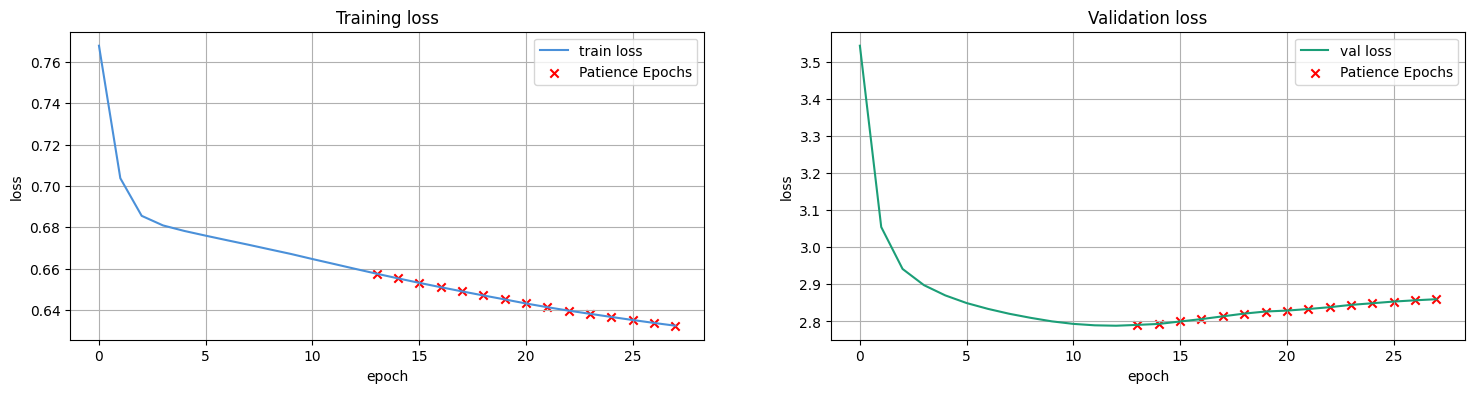

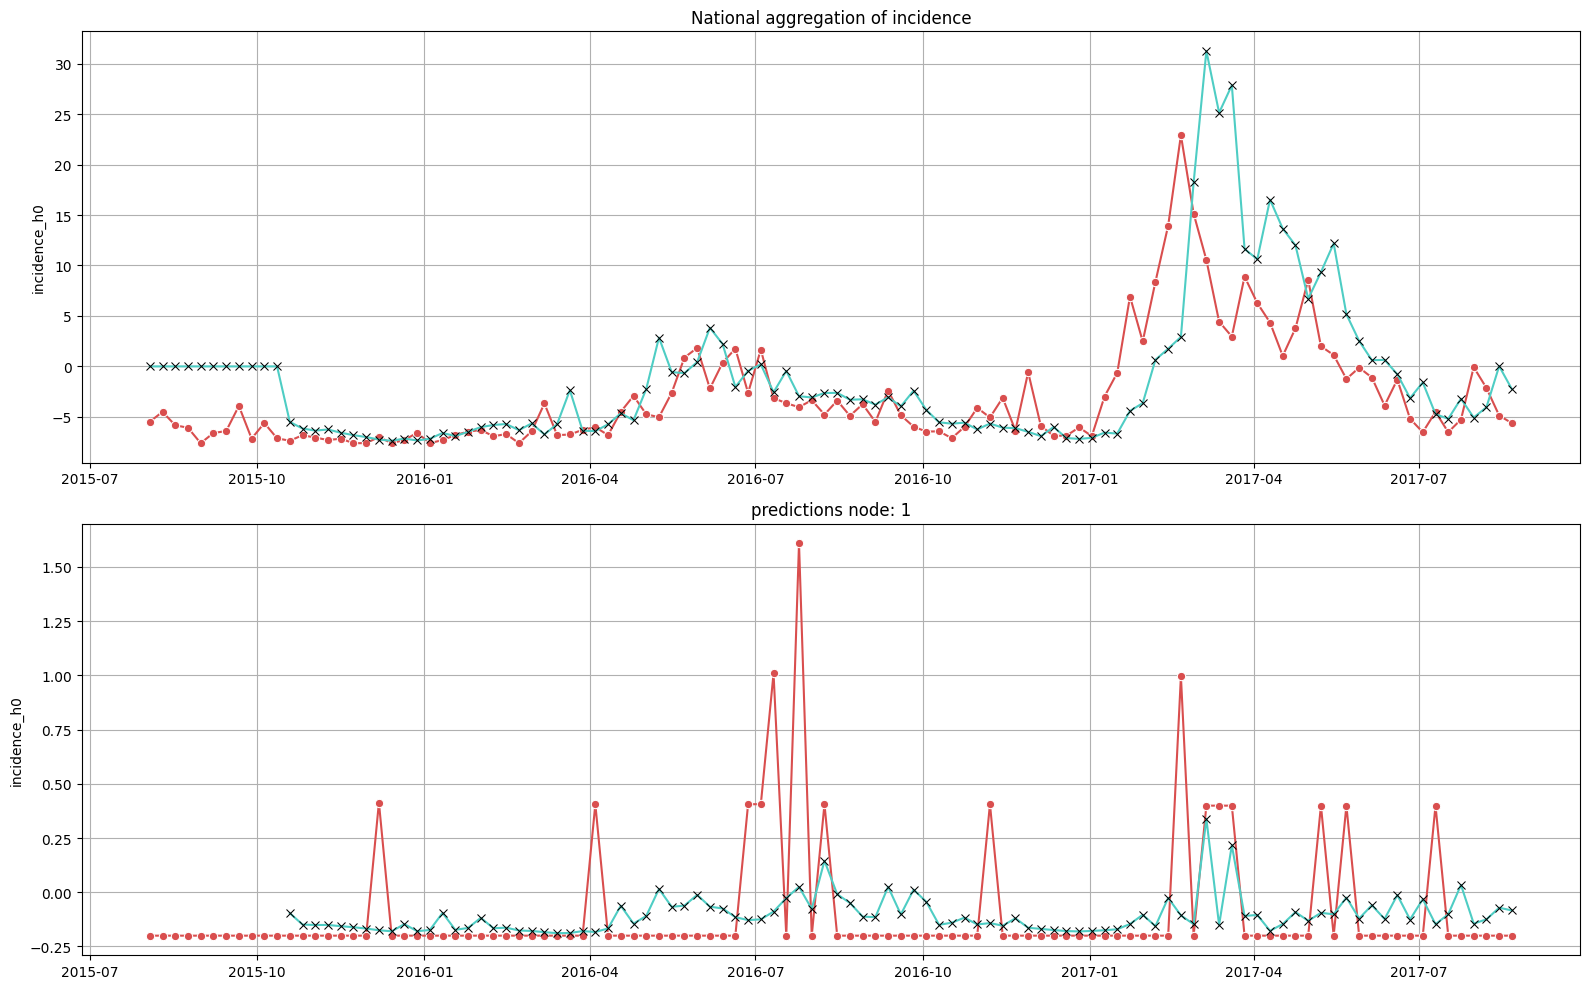

In [34]:
n_epochs = 100
lr       = 0.0001


epidata_nuts2 = GNNDataLoader('measles', data_env, nuts_level='nuts2', min_date='2006-01-15',max_date='2017-06-01', include_population=True, periods = 12, prediction_horizon=4)
epidata_nuts2.add_time_features()
epidata_nuts2.log_transform_target()
epidata_nuts2.set_splits(split_trainval='2014-06-01',split_valtest='2015-08-01')
epidata_nuts2.normalize()
epidata_nuts2.add_lagged_features(lags = range(2,3))
epidata_nuts2.finalize()

epidata_nuts2_id  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'identity_graph').construct_dataloaders()
epidata_nuts2_bn  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'boolean_neighbors_self0').construct_dataloaders()
epidata_nuts2_gm1 = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'gravity_model_dense').construct_dataloaders()
epidata_nuts2_gm2 = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'gravity_model_sparse').construct_dataloaders()


ml1_id = SpatialGCNModel(name = f'spatial gcn - identity graph', dataloader=epidata_nuts2_id)
ml1_id.set_model_hparams()
ml1_id.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml1_id.run_snapshot(debug=True)
ml1_id.train(verbose=2)
ml1_id.forecast()
ml1_id.show_forecasts(dataset='test', target_h = 0)

ml1_bn = SpatialGCNModel(name = f'spatial gcn - boolean neighbors', dataloader=epidata_nuts2_bn)
ml1_bn.set_model_hparams()
ml1_bn.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml1_bn.run_snapshot(debug=True)
ml1_bn.train(verbose=2)
ml1_bn.forecast()
ml1_bn.show_forecasts(dataset='test', target_h = 0)

ml1_gm1 = SpatialGCNModel(name = f'spatial gcn - gravity model1', dataloader=epidata_nuts2_gm1)
ml1_gm1.set_model_hparams()
ml1_gm1.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml1_gm1.run_snapshot(debug=True)
ml1_gm1.train(verbose=2)
ml1_gm1.forecast()
ml1_gm1.show_forecasts(dataset='test', target_h = 0)

ml1_gm2 = SpatialGCNModel(name = f'spatial gcn - gravity model2', dataloader=epidata_nuts2_gm2)
ml1_gm2.set_model_hparams()
ml1_gm2.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml1_gm2.run_snapshot(debug=True)
ml1_gm2.train(verbose=2)
ml1_gm2.forecast()
ml1_gm2.show_forecasts(dataset='test', target_h = 0)

GNN temporal windowing: extending data collection from 2020-06-01 to 2020-06-29 (+4 weeks)
Dataloader Snapshot: <src.dataloading.graphdataloader.GraphDataLoaderEntry object at 0x7f48817277d0>
Epoch 1 train loss: 0.4294, val loss: 0.6793 ✓ (new best)
Epoch 11 train loss: 0.3001, val loss: 0.3904 ✓ (new best)
Epoch 21 train loss: 0.2726, val loss: 0.3692 ✓ (new best)
Epoch 31 train loss: 0.2580, val loss: 0.3648 ✓ (new best)
Epoch 41 train loss: 0.2454, val loss: 0.3620 (patience: 1/15)
Epoch 51 train loss: 0.2376, val loss: 0.3617 ✓ (new best)
Epoch 61 train loss: 0.2300, val loss: 0.3608 ✓ (new best)
Epoch 71 train loss: 0.2259, val loss: 0.3600 ✓ (new best)
Epoch 81 train loss: 0.2208, val loss: 0.3590 (patience: 2/15)
Epoch 91 train loss: 0.2178, val loss: 0.3580 (patience: 1/15)
Epoch 101 train loss: 0.2137, val loss: 0.3574 (patience: 2/15)
Epoch 111 train loss: 0.2114, val loss: 0.3554 ✓ (new best)
Epoch 121 train loss: 0.2079, val loss: 0.3551 (patience: 2/15)
Epoch 131 train los

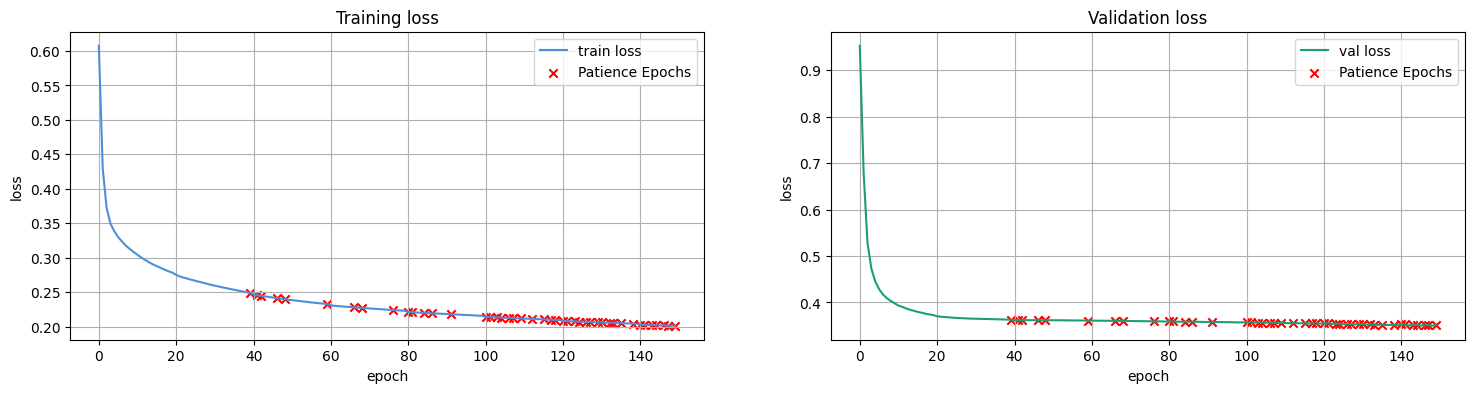

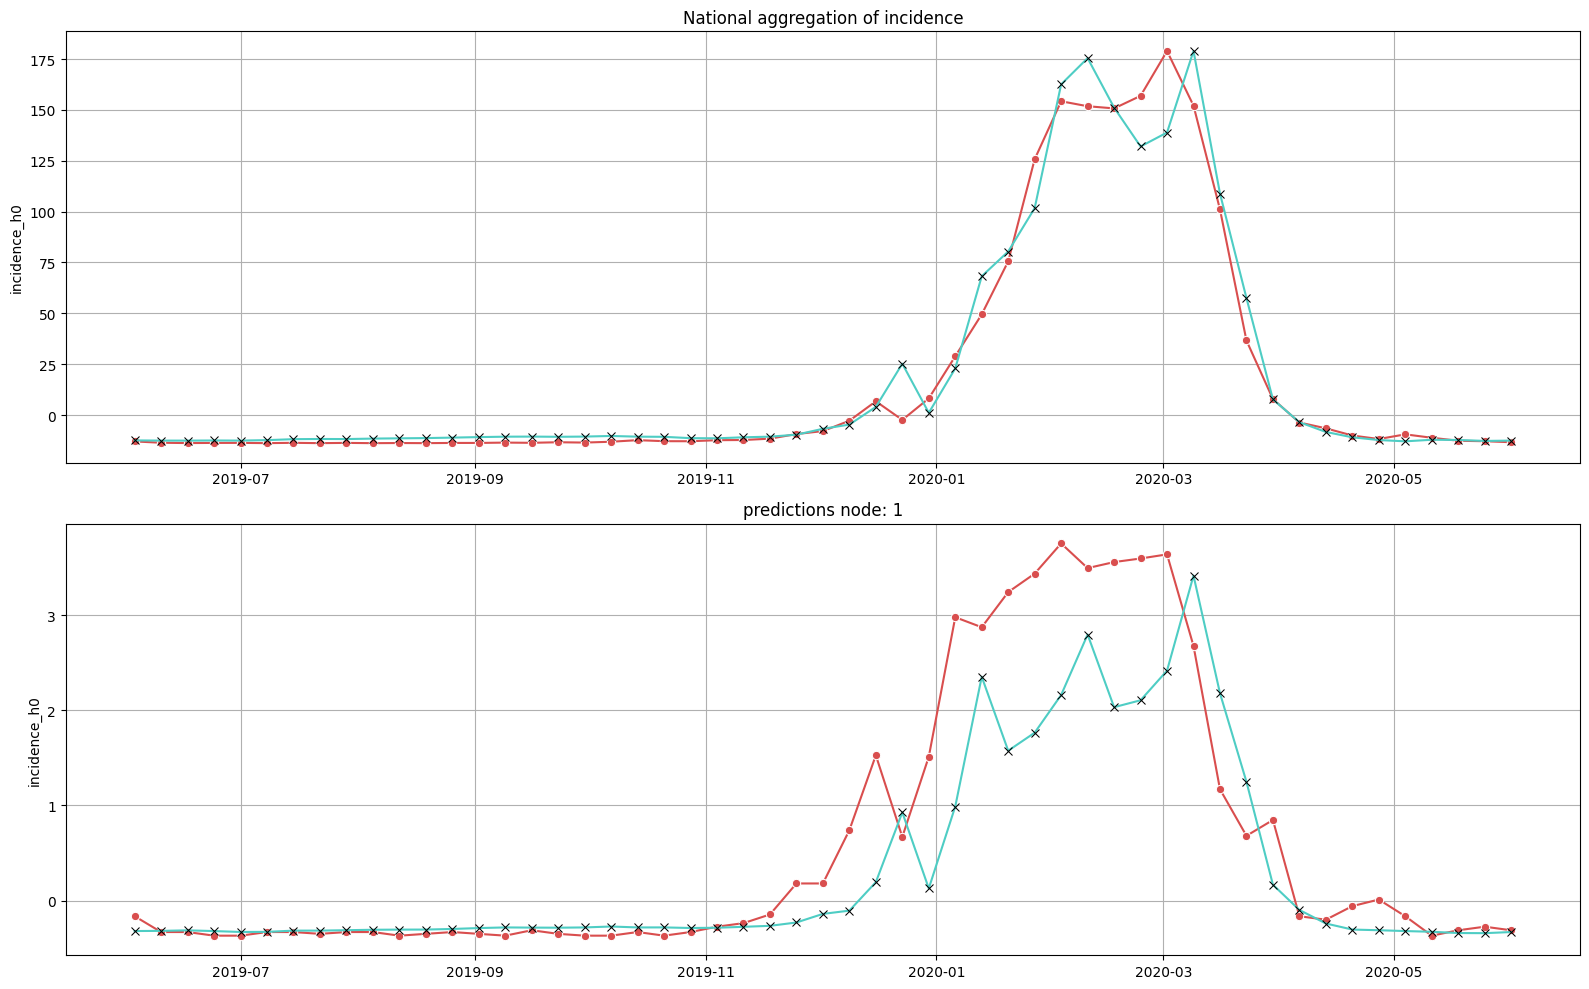

In [8]:
from src.dataloading.gnndataloader import GNNDataLoader


n_periods = 1
n_epochs  = 100
horizon   = 4
lags      = range(1,4)


epidata_nuts2 = GNNDataLoader('influenza', data_env, nuts_level='nuts2', min_date='2006-05-15',max_date='2020-06-01', include_population=True, periods = n_periods, prediction_horizon=horizon)
epidata_nuts2.add_time_features()
epidata_nuts2.log_transform_target()
epidata_nuts2.set_splits()
epidata_nuts2.normalize()
epidata_nuts2.add_lagged_features(lags = lags)
epidata_nuts2.finalize()
epidata_nuts2.retrieve_graph('gravity_model_sparse')
epidata_nuts2.construct_dataloaders()

n_epochs = 150
lr = 0.0001

ml1 = SpatialGCNModel(name = f'influenza id graph', dataloader=epidata_nuts2)
ml1.set_model_hparams()
ml1.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml1.train()
ml1.forecast()
ml1.show_forecasts(dataset='test', target_h = 0)

In [31]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
from typing import Literal
import pandas as pd

def show_forecasts_maps(ml,
                        dataset: Literal['train','val','test'],                       
                        tt: int,
                        scale: Literal['constant','equal','individual']):

    evaluation_df = ml.evaluation_datasets[dataset]
    dates = evaluation_df[ml.dataloader.temporal_column].unique()
    date = dates[tt]
    
    shapedata = ml.dataloader.data['context']['shapedata']
    map_tt = gpd.GeoDataFrame(
        pd.merge(
            evaluation_df[evaluation_df[ml.dataloader.temporal_column] == date],
            shapedata,
            on='node'
        )
    )

    if scale == 'constant':
        vmin, vmax = evaluation_df['incidence_h0'].min(), evaluation_df['incidence_h0'].max()
    elif scale == 'equal':
        vmin, vmax = map_tt['incidence_h0'].min(), map_tt['incidence_h0'].max()
    else:
        vmin = vmax = None

    # Make room on the right for the colorbar by adjusting subplot params
    fig, axes = plt.subplots(1, 2, figsize=(14, 8), gridspec_kw={'width_ratios': [1,1], 'wspace': 0.1})
    
    # Shrink subplots a bit to the left for colorbar space
    plt.subplots_adjust(right=0.85)  # leave 15% of figure width for colorbar on right

    # Plot without legend
    map_tt.plot(column='incidence_h0', cmap='coolwarm', ax=axes[0], legend=False, vmin=vmin, vmax=vmax)
    axes[0].set_title('True incidence')

    map_tt.plot(column='pred_h0', cmap='coolwarm', ax=axes[1], legend=False, vmin=vmin, vmax=vmax)
    axes[1].set_title('Predicted incidence')

    fig.suptitle(f'Predicted normalized incidence rates influenza at {date.date()}')

    # Add colorbar on the right only if scale == 'equal'
    if scale == 'equal':
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=norm)
        sm._A = []

        # Position colorbar in a new axes on the far right
        cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])  # [left, bottom, width, height] in figure coords
        cbar = fig.colorbar(sm, cax=cbar_ax)
        cbar.set_label('Normalized incidence')
    for ax in axes:
        ax.set_axis_off()
    plt.show()


In [30]:
ml1.evaluation_datasets['test']

,timestamp,node,population_size,timestamp_sin,timestamp_cos,incidence_lag1,incidence_lag2,incidence_lag3,train,val,test,incidence_h0,incidence_h1,incidence_h2,incidence_h3,pred_h0,pred_h1,pred_h2,pred_h3
0,2019-06-03,0,0.680621,0.49831,-1.318102,-0.345464,-0.134038,-0.285457,False,False,True,-0.333381,-0.261736,-0.369755,-0.357589,-0.286230,-0.299500,-0.308249,-0.279289
1,2019-06-03,1,-0.272423,0.49831,-1.318102,-0.111226,-0.201405,0.011285,False,False,True,-0.165057,-0.331646,-0.331646,-0.369755,-0.321072,-0.337828,-0.348880,-0.320406
2,2019-06-03,2,-0.500035,0.49831,-1.318102,-0.325654,-0.347636,-0.282096,False,False,True,-0.347636,-0.369755,-0.347636,-0.369755,-0.354630,-0.376868,-0.394087,-0.373381
3,2019-06-03,3,-0.000917,0.49831,-1.318102,-0.353320,-0.336961,-0.272269,False,False,True,-0.369755,-0.369755,-0.369755,-0.369755,-0.352023,-0.371835,-0.385071,-0.363581
4,2019-06-03,4,-0.390417,0.49831,-1.318102,-0.369755,-0.369755,-0.328758,False,False,True,-0.369755,-0.369755,-0.369755,-0.369755,-0.305344,-0.321889,-0.332446,-0.304924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2009,2020-06-01,33,-0.663487,0.49831,-1.318102,-0.369755,-0.369755,-0.344811,False,False,True,-0.369755,-0.344811,-0.369755,-0.369755,-0.345194,-0.346379,-0.332974,-0.348008
2010,2020-06-01,34,-0.504582,0.49831,-1.318102,-0.369755,-0.303601,-0.325515,False,False,True,-0.347566,-0.369755,-0.347566,-0.369755,-0.321017,-0.326250,-0.328094,-0.340049
2011,2020-06-01,35,-0.988596,0.49831,-1.318102,-0.369755,-0.237854,-0.336316,False,False,True,-0.369755,-0.369755,-0.369755,-0.369755,-0.341068,-0.355101,-0.369043,-0.373864
2012,2020-06-01,36,0.028351,0.49831,-1.318102,-0.369755,-0.369755,-0.369755,False,False,True,-0.353564,-0.369755,-0.369755,-0.353564,-0.348066,-0.363523,-0.383032,-0.382411


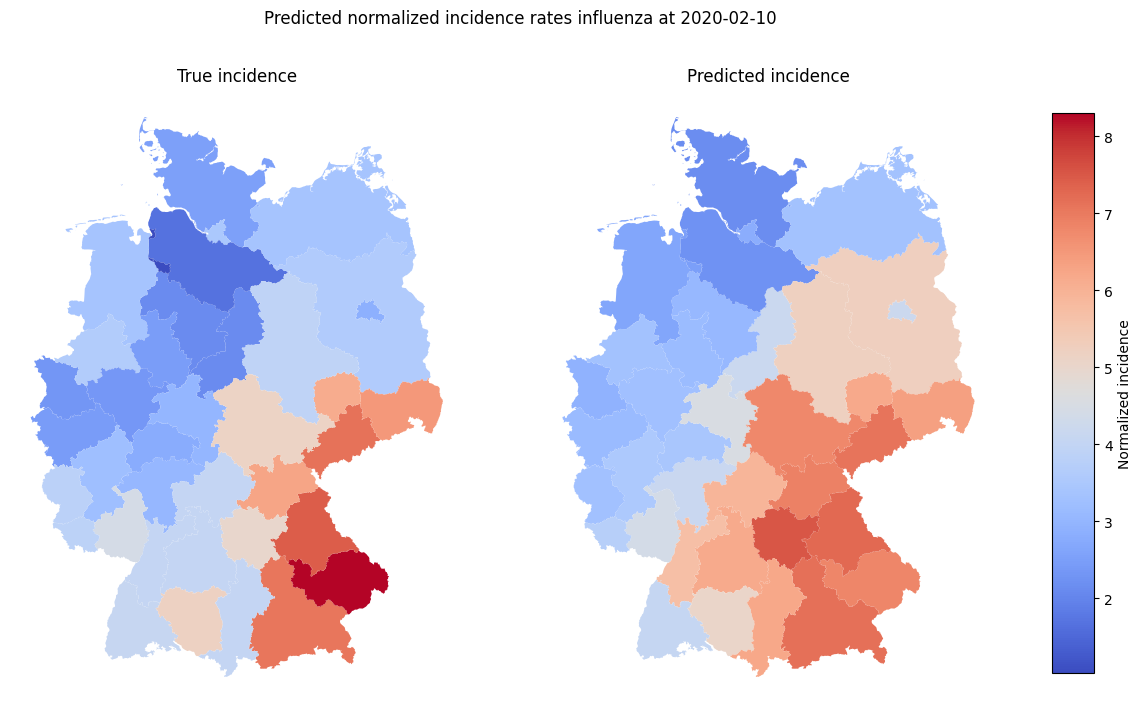

In [36]:
show_forecasts_maps(ml1, 'test', 36, 'equal')

Test loss: 0.3772


KeyError: 'incidence'

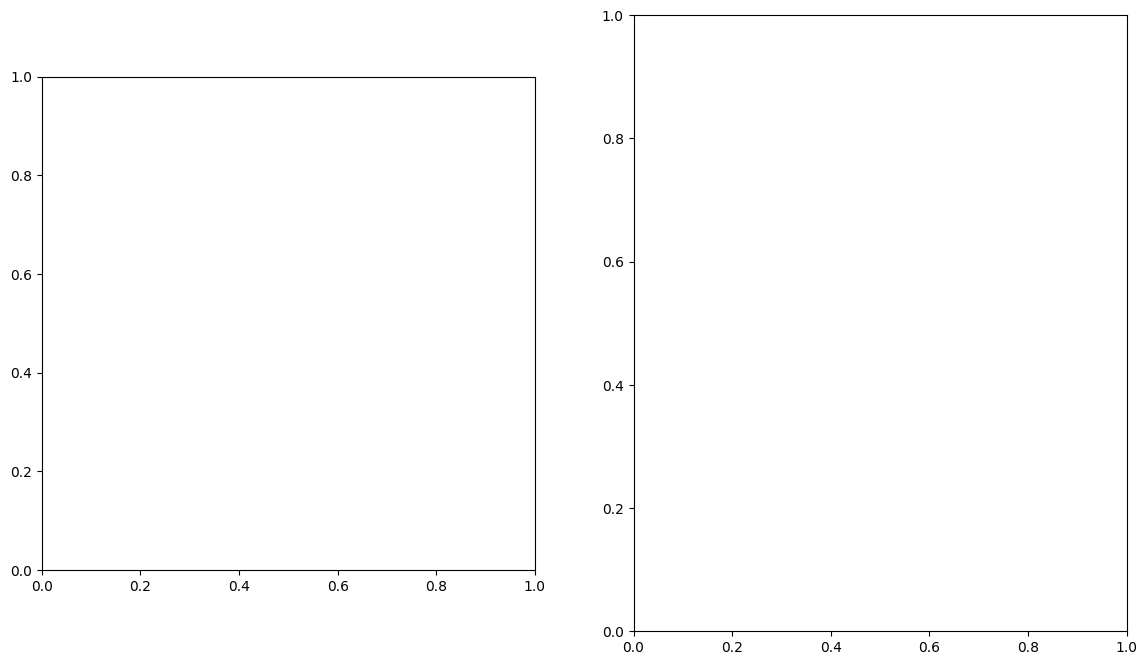

In [6]:
ml1.forecast('test')
ml1.show_forecasts_maps('test',35,'individual')